# Analyzing 2D Flux Sweeps

## Imports and Notes

Note: Data should be exported with the coil yoko on the x axis and the dc yoko on the y axis

Concerns: That the lack of restriction on the domain of the autocorrelation (specifically for finding the zero) is biasing the autocorrelation slightly to the wrong point. Should have a restricted domain on only one period for one of the images.

In [50]:
# MAKE SURE DATA IS NORMALIZED BEFORE READING IT IN
import scipy
import sys
import os
import IPython
import numpy as np
import matplotlib as mpl
import pandas as pd
from pathlib import Path
from PIL import Image
import scipy.signal
from scipy.optimize import curve_fit
import scipy.constants as cst
from matplotlib import pyplot as plt
# from qutip import*
# import graphsettings

In [51]:
#choose a quadrant to search (not like an array, like counter-clockwise graphing quadrants)
def find_max_pt(correlation, which_quadrant: int, bias_x: int, bias_y: int) -> np.ndarray:
    '''Finds the maximum within the specified quadrant given biases
    Quadrant ordering is counter-clockwise like graphing, not like an array'''
    x = np.shape(correlation)[1]
    y = np.shape(correlation)[0]
    if which_quadrant == 1:
        (x_bounds_start, x_bounds_end) = (int(x/2)+bias_x, x)
        (y_bounds_start, y_bounds_end) = (int(y/2)+bias_y, y)

    elif which_quadrant == 2:
        (x_bounds_start, x_bounds_end) = (0, int(x/2)-bias_x)
        (y_bounds_start, y_bounds_end) = (int(y/2)+bias_y, y)

    elif which_quadrant == 3:
        (x_bounds_start, x_bounds_end) = (0, int(x/2)-bias_x)
        (y_bounds_start, y_bounds_end) = (0, int(y/2)-bias_y)

    elif which_quadrant == 4:
        (x_bounds_start, x_bounds_end) = (int(x/2)+bias_x, x)
        (y_bounds_start, y_bounds_end) = (0, int(y/2)-bias_y)

    #calculates the correct portion of the correlation grid
    quadrant = correlation[y_bounds_start:y_bounds_end, x_bounds_start:x_bounds_end, ]
    max_value = float('-inf')
    max_index = None

    for i in range(len(quadrant)):
        for j in range(len(quadrant[i])):
            if quadrant[i][j] > max_value:
                max_value = quadrant[i][j]
                
                if which_quadrant == 1:
                    max_index = (j + bias_x, i + bias_y)
                elif which_quadrant == 2:
                    max_index = (j - int(x/2), i + bias_y)
                elif which_quadrant == 3:
                    max_index = (j - int(x/2), i - int(y/2))
                elif which_quadrant == 4:
                    max_index = (j + bias_x, i - int(y/2))

    print(f'Quadrant {which_quadrant}:',
          f'\nIndicies for (DC, Coil) = {max_index}',
          f"\nCurrent values for (DC, Coil) = ({max_index[0]*dc_step}, {max_index[1]*coil_step})\n")
    return max_index

## Import raw data and scale axes

Data shape: (351, 351) DC (351,) (351,)


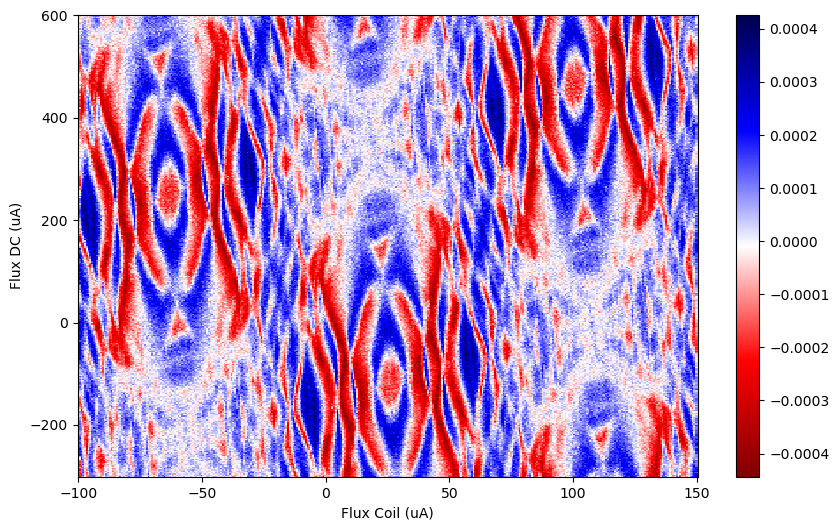

In [105]:
#Read-in data
# MAKE SURE DATA IS NORMALIZED BEFORE READING IT IN
nprry = np.loadtxt('Data/2025-02-04/c2phi_fine_large', dtype=complex).T
data = np.abs(nprry)
data = data - np.mean(data)
# df = pd.read_csv('Data/2025-02-02/c2phi_fine_large',sep="\t")
# df = np.array(df)
# data = np.transpose(df)

#Defining range for coil
coil_start = -100
coil_end =  150# uA
# coil_step = 351
coil_num = 351 #(coil_end-coil_start)/coil_step + 1
coil_step = (coil_end-coil_start)/coil_num
coil = np.linspace(coil_start, coil_end, int(coil_num))

#Defining range for on-chip
dc_start = -300
dc_end = 600 # uA
# dc_step = 600
dc_num = 351 #(dc_end-dc_start)/dc_step + 1
dc_step = (dc_end - dc_start)/dc_num
dc = np.linspace(dc_start, dc_end, int(dc_num))

# Run if you need to reverse every second row due to serpentine aquisition
# data = []
# for i, row in enumerate(df):
#     if i%2 == 0:
#         data.append(np.array( row, dtype=float) )
#     else:
#         data.append(np.array( 
#             np.flip(row), 
#             dtype=float ) )

#Show data to confirm all went well
print('Data shape:', np.shape(data), 'DC', np.shape(dc), np.shape(coil))
fig, ax = plt.subplots(figsize = (10,6))
c = ax.pcolor(coil, dc,  data, shading='nearest', cmap='seismic_r')
fig.colorbar(c)
ax.set_xlabel('Flux Coil (uA)');
ax.set_ylabel('Flux DC (uA)');

## Find basis vectors through autocorrelation

Note: This will be the basis vectors for the 2D periodic scan, but in general, a transformation will be necessary to return these vectors back to $\theta$ and $\phi$

### Find Maximum in each quadrant

Quadrant 1: 
Indicies for (DC, Coil) = (225, 105) 
Current values for (DC, Coil) = (576.923076923077, 74.78632478632478)

Quadrant 4: 
Indicies for (DC, Coil) = (142, -125) 
Current values for (DC, Coil) = (364.10256410256414, -89.03133903133903)

Quadrant 1: 
Indicies for (DC, Coil) = (83, 230) 
Current values for (DC, Coil) = (212.82051282051285, 163.81766381766383)

83 230


IndexError: index 405 is out of bounds for axis 0 with size 351

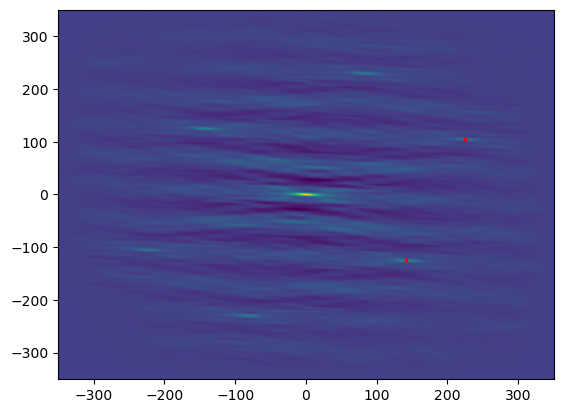

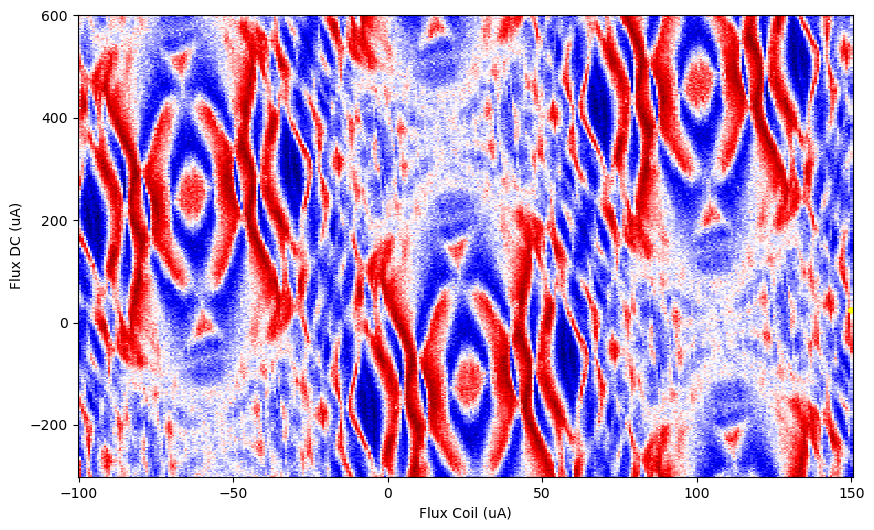

In [101]:
#Finding autocorrelation
correlation = scipy.signal.correlate(data.T, data.T)
coil_correlation = correlation.shape[1] #why is this reversed?
dc_correlation = correlation.shape[0] #why is this reversed?
dc_axis = np.linspace(-int(dc_correlation/2), int(dc_correlation/2), dc_correlation)
coil_axis = np.linspace(-int(coil_correlation/2), int(coil_correlation/2), coil_correlation)

plt.pcolormesh(coil_axis, dc_axis, correlation)

dc_index, coil_index = find_max_pt(correlation, 1, 120, 40)
plt.scatter(dc_index, coil_index, s=3, color='red');
dc_index, coil_index = find_max_pt(correlation, 4, 40, 40)
plt.scatter(dc_index, coil_index, s=3, color='red');

fig, ax = plt.subplots(figsize = (10,6))
ax.pcolor(coil, dc,  data, cmap='seismic_r')
ax.set_xlabel('Flux Coil (uA)')
ax.set_ylabel('Flux DC (uA)')
ax.scatter(dc[int(dc_num/2)], coil[int(coil_num/2)], s=15, color='yellow');
dc_index, coil_index = find_max_pt(correlation, 1, 40, 110)
print(dc_index, coil_index)
ax.scatter(dc[coil_index+int(dc_num/2)], coil[dc_index+int(coil_num/2)], s=15, color='yellow');
dc_index, coil_index = find_max_pt(correlation, 4, 40, 40)
ax.scatter(dc[coil_index+int(dc_num/2)], coil[dc_index+int(coil_num/2)], s=15, color='yellow');

## Find symmetry point

### Rotation Techniques

Text(0.5, 1.0, 'Original Unrotated Data')

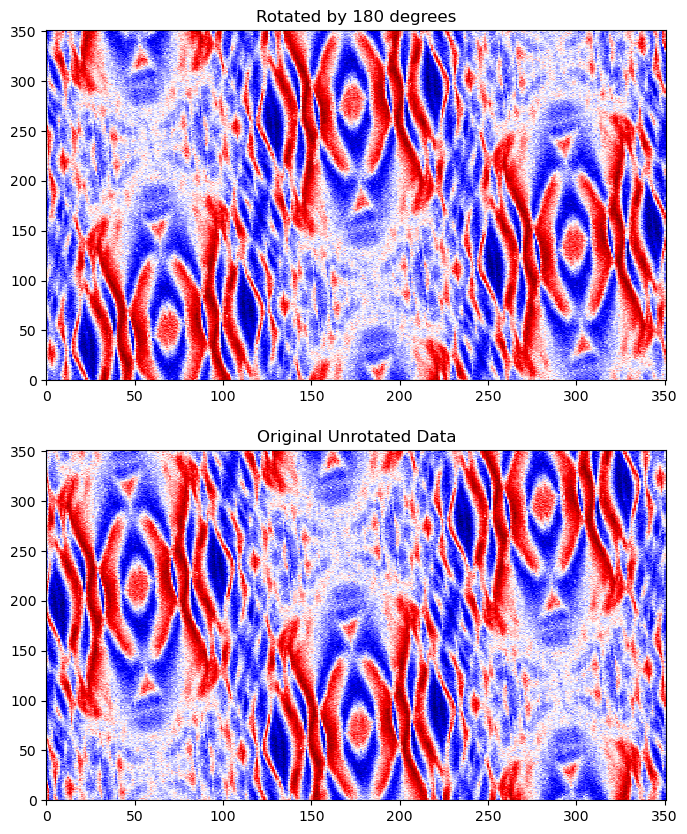

In [71]:
rotated_image = np.rot90(data, 2)

fig, ax = plt.subplots(nrows=2, figsize = (8,10))
ax[0].pcolor(rotated_image, cmap='seismic_r')
ax[0].set_title('Rotated by 180 degrees')
ax[1].pcolor(data, cmap='seismic_r')
ax[1].set_title('Original Unrotated Data')

(701,) (701,) (701, 701)
Symmetry point indicies: (DC, Coil) = (458, 370) 
Real offset: (DC, Coil) = (108.0, 20.0)


C:\Users\QNL\AppData\Local\Temp\ipykernel_7760\3680296976.py:14: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(dc_correlation, coil_correlation, correlation, shading='nearest');


195 283
201.42857142857144 102.14285714285714


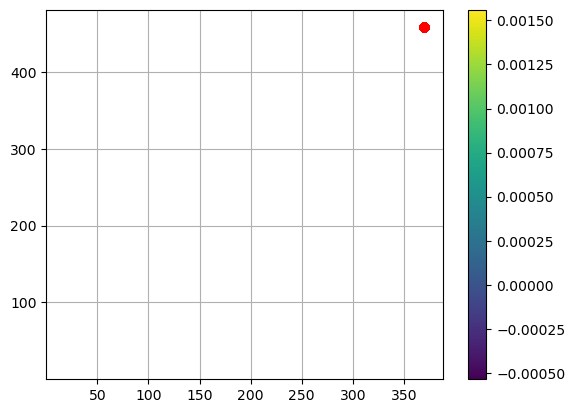

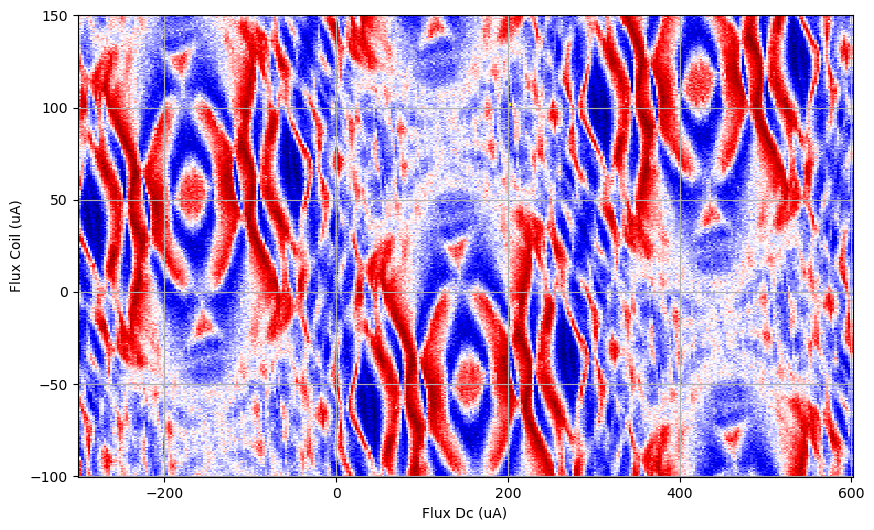

In [72]:
#Finding autocorrelation
correlation = scipy.signal.correlate(data, rotated_image)
#column number (second index) is x, row number (first index) is y as according to convention
dc_correlation = correlation[:,1]
coil_correlation = correlation[:,0]

print(np.shape(dc_correlation), np.shape(coil_correlation), np.shape(correlation))

max_index = np.unravel_index(correlation.argmax(), correlation.shape)
max_index = max_index[::-1]

print(f'Symmetry point indicies: (DC, Coil) = {max_index}',
      f'\nReal offset: (DC, Coil) = {dc_axis[max_index[0]], coil_axis[max_index[1]]}')
plt.pcolormesh(dc_correlation, coil_correlation, correlation, shading='nearest');
plt.colorbar();
plt.scatter(max_index[1]-dc_correlation/2, max_index[0]-coil_correlation/2, c='r');
plt.grid()


fig, ax = plt.subplots(figsize = (10,6))
ax.pcolor(dc, coil,  data, cmap='seismic_r')
ax.set_xlabel('Flux Dc (uA)')
ax.set_ylabel('Flux Coil (uA)')
dc_sym_index = max_index[1]-int(dc_num/2)
coil_sym_index = max_index[0]-int(coil_num/2)
print(dc_sym_index, coil_sym_index)
print(dc[dc_sym_index], coil[coil_sym_index])
ax.scatter(dc[dc_sym_index], coil[coil_sym_index], s=3, color='yellow');
ax.grid()
# ax.scatter(dc[dc_index+int(dc_num/2)], coil[coil_index+int(coil_num/2)], s=3, color='red');

Quadrant 1: 
Indicies for (DC, Coil) = (20, 108) 
Current values for (DC, Coil) = (51.282051282051285, 76.92307692307692)

Symmetry point indicies: (DC, Coil) = (20, 108)
185 229
63.571428571428584 175.71428571428572
63.571428571428584 175.71428571428572


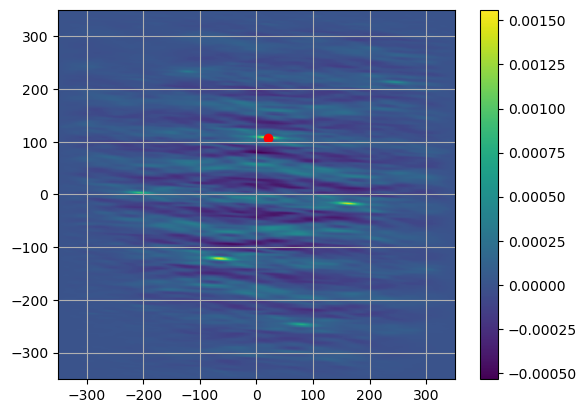

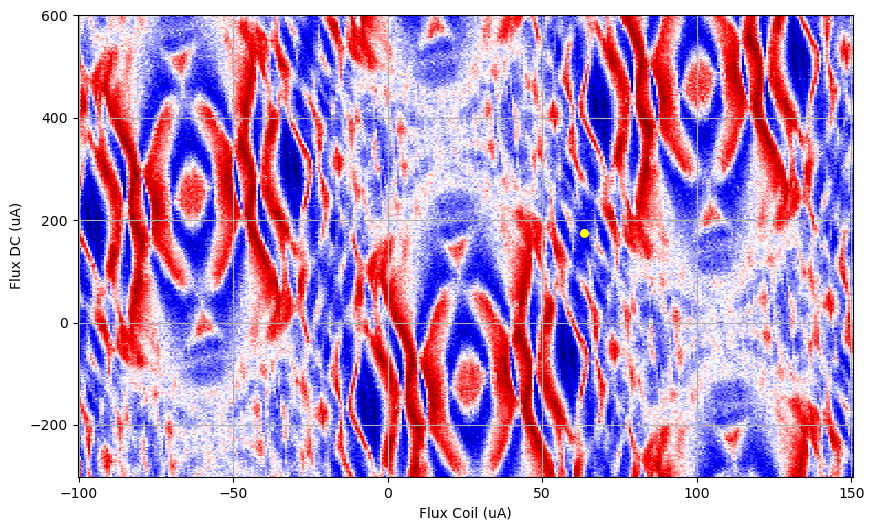

In [88]:
#Finding autocorrelation
correlation = scipy.signal.correlate(data, rotated_image).T
#column number (second index) is x, row number (first index) is y as according to convention
dc_correlation = correlation.shape[0]
coil_correlation = correlation.shape[1]
dc_axis = np.linspace(-int(dc_correlation/2), int(dc_correlation/2), dc_correlation)
coil_axis = np.linspace(-int(coil_correlation/2), int(coil_correlation/2), coil_correlation)

max_value = float('-inf')
max_index = None

dc_index, coil_index = find_max_pt(correlation, 1, 5, 5)
# max_index = max_index[::-1]
print(f'Symmetry point indicies: (DC, Coil) = {dc_index, coil_index}')
plt.pcolormesh(dc_axis, coil_axis, correlation);
plt.colorbar();
plt.scatter(dc_index, coil_index, c='r');
plt.grid()

dc_index = int(dc_index/2 + int(dc_num/2))
coil_index = int(coil_index/2 + int(coil_num/2))
print(dc_index, coil_index)
fig, ax = plt.subplots(figsize = (10,6))
ax.pcolor(coil, dc,  data, cmap='seismic_r')
ax.set_xlabel('Flux Coil (uA)')
ax.set_ylabel('Flux DC (uA)')
print(coil[coil_index], dc[dc_index])
ax.scatter(coil[coil_index], dc[dc_index], s=30, color='yellow');
print(coil[coil_index], dc[dc_index])
ax.grid()
# ax.scatter(dc[dc_index+int(dc_num/2)], coil[coil_index+int(coil_num/2)], s=3, color='red');

TypeError: 'NoneType' object is not subscriptable

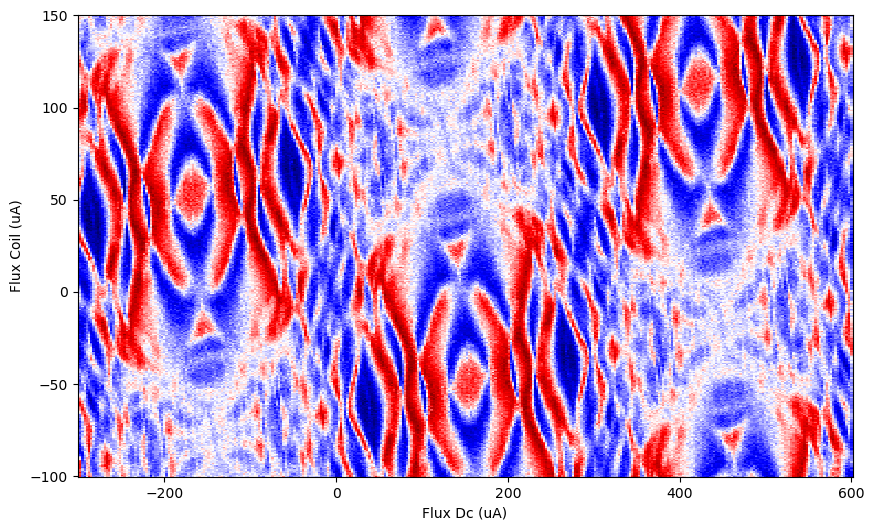

In [45]:
fig, ax = plt.subplots(figsize = (10,6))
ax.pcolor(dc, coil,  data, cmap='seismic_r')
ax.set_xlabel('Flux Dc (uA)')
ax.set_ylabel('Flux Coil (uA)')
dc_sym_index = max_index[1]-int(dc_num/2)
coil_sym_index = max_index[0]-int(coil_num/2)
ax.scatter(dc[dc_sym_index], coil[coil_sym_index], s=3, color='yellow');
ax.scatter(dc[int(351/2)], coil[int(351/2)], s=15, color='yellow');
ax.grid()
# ax.scatter(dc[dc_index+int(dc_num/2)], coil[coil_index+int(coil_num/2)], s=3, color='red');

TypeError: Dimensions of C (351, 351) should be one smaller than X(351) and Y(350) while using shading='flat' see help(pcolor)

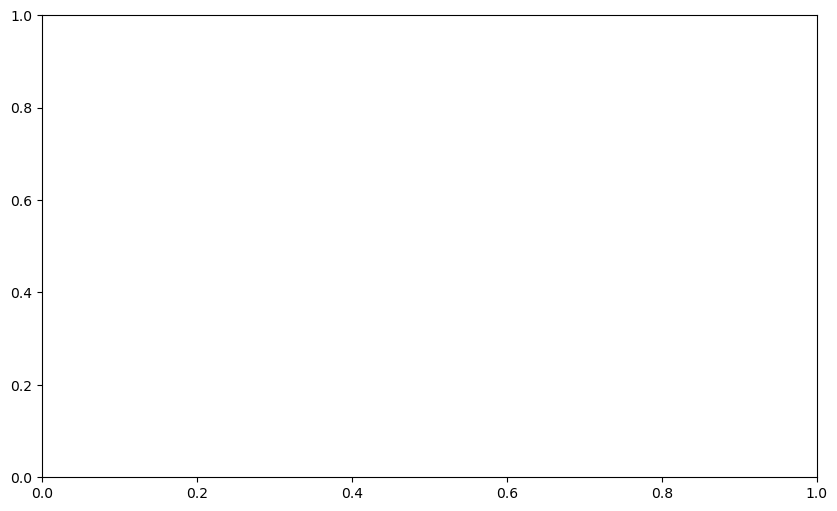

In [36]:
fig, ax = plt.subplots(nrows=1, figsize = (10,6))
ax.pcolor(dc, coil[:-1], data, cmap='seismic_r')
coordinate = [y_axis[max_index[0]]/2 + (data.shape[0]+1)/2, x_axis[max_index[1]]/2+ (data.shape[1]+1)/2 ]
ax.scatter((dc[int(coordinate[1])]+dc[int(coordinate[1])+1])/2, (coil[int(coordinate[0])]+coil[int(coordinate[0])+1])/2, color='red', s=3)
print(f'DC = {(dc[int(coordinate[1])]+dc[int(coordinate[1])+1])/2}, Coil = {(coil[int(coordinate[0])]+coil[int(coordinate[0])+1])/2}')

In [ ]:
print(coordinate)

# Two Tone

In [ ]:
two_tone_data_file1 = os.path.join(data_folder, f'GKP_v2_X6Y6_GKP1_two_tone_flux_2.txt')

df = pd.read_csv(two_tone_data_file1, sep="\t")


currents1 = np.linspace(-166, 575, 79)
freqs1 = np.linspace(1.5, 4.5, 1501)

In [ ]:
two_tone_data_file2 = os.path.join(data_folder, f'GKP_v2_X6Y6_GKP1_two_tone_flux_3.txt')

df2 = pd.read_csv(two_tone_data_file2, sep="\t")


currents2 = np.linspace(-1021, -166, 91)
freqs2 = np.linspace(.01, 4.5, 2246)

In [ ]:
two_tone_data_file4 = os.path.join(data_folder, f'GKP_v2_X6Y6_GKP1_two_tone_flux_4.txt')

df4 = pd.read_csv(two_tone_data_file4, sep="\t")


currents4 = np.linspace(-166, 689, 91)
freqs4 = np.linspace(4.5, 8.0, 1751)

In [ ]:
df.shape

In [ ]:
fig, ax = plt.subplots(figsize=(6,10))

im = ax.pcolor(currents1, freqs1, df.transpose(), vmin=-5, vmax=5, cmap='seismic')
ax.pcolor(currents2, freqs2, df2.transpose(), vmin=-5, vmax=5, cmap='seismic')
ax.pcolor(currents4, freqs4, df4.transpose(), vmin=-3, vmax=3, cmap='seismic')


ax.set_xlabel('Yoko Current (uA)')
ax.set_ylabel('Frequency (GHz)')
# ax.set_ylim([2, 2.5])
ax.axhline(2.222)

## 0 flux regime

In [ ]:
zero_flux_two_tone_data_file1 = os.path.join(data_folder, f'GKP_v2_X6Y6_GKP1_two_tone_flux_0flux_regime.txt')

zero_flux_df = pd.read_csv(zero_flux_two_tone_data_file1, sep="\t")


currents1 = np.linspace(-444, 1266, 181)
freqs1 = np.linspace(1, 6, 2501)

In [ ]:
zero_flux_two_tone_data_file2 = os.path.join(data_folder, f'GKP_v2_X6Y6_GKP1_two_tone_flux_0flux_regime_2.txt')

zero_flux_df2 = pd.read_csv(zero_flux_two_tone_data_file2, sep="\t")


currents2 = np.linspace(-444, 1266, 181)
freqs2 = np.linspace(.01, 1, 991)

In [ ]:
fig, ax = plt.subplots(figsize=(6,10))

im = ax.pcolor(currents1, freqs1, zero_flux_df.transpose(), vmin=-5, vmax=5, cmap='seismic')
ax.pcolor(currents2, freqs2, zero_flux_df2.transpose(), vmin=-10, vmax=10, cmap='seismic')


ax.set_xlabel('Yoko Current (uA)')
ax.set_ylabel('Frequency (GHz)')
# ax.set_ylim([2, 2.5])
# ax.axhline(2.222)

#### Clicker for half flux

In [ ]:
from mpl_point_clicker import clicker
import matplotlib
import PyQt5
matplotlib.use('QtAgg')

In [ ]:
import IPython
%matplotlib qt

from matplotlib import pyplot as plt


two_tone_data_file2 = os.path.join(data_folder, f'GKP_v2_X6Y6_GKP1_two_tone_flux_3.txt')

df2 = pd.read_csv(two_tone_data_file2, sep="\t")


currents2 = (np.linspace(-1021, -166, 91)+ 1021)/855/2
freqs2 = np.linspace(.01, 4.5, 2246)

fig,ax = plt.subplots(figsize = [7,20])
X,Y = np.meshgrid(currents2, freqs2)
Z = df2.transpose()
plt.pcolormesh(X,Y,Z, 
               vmin = -5, vmax = 5, 
               cmap = 'seismic')
plt.xlabel('Current (mA)')
plt.ylabel('Frequency (GHz)')
plt.axvline(0.5)
plt.colorbar()
plt.grid()
klicker = clicker(ax, ["event"], markers=["x"])
plt.show()

In [ ]:
plt.close('all')
clicked_points=klicker.get_positions()
clicked_points

# Fitting

In [ ]:
import scqubits as scq


## Parameters

In [ ]:
gkp_yaml = """branches:
- [JJ, 1,3, 6.7, 0.4]
- [JJ, 1,4, 6.7, 0.4]
# - [C, 1,2, eC=1.2]
- [L, 2,3, 0.4]
- [L, 2,4, 0.4]
- [L, 2,5, 0.19]
- [JJ, 5,1, 4, 10]
"""
gkp = scq.Circuit(gkp_yaml, from_file=False, basis_completion="canonical", ext_basis = "discretized")

In [ ]:
trans_mat =  np.array([[1.,  0.,   0.,  0., 1],
                       [0.,  0.,   0.,  1., 1],
                       [0.,  1.,   1.,  0., 1],
                       [0,  -1.,   1.,  0., 1], 
                       [0.,  0.,   0.,  0., 1]])

In [ ]:
gkp.configure(transformation_matrix=trans_mat, closure_branches=[gkp.branches[0], gkp.branches[-1]])
gkp.sym_hamiltonian()#.subs("EJ", gkp.EJ).subs("EL", gkp.EL).subs("eL", gkp.eL)

In [ ]:
%%time
gkp.cutoff_n_1 = 4
gkp.cutoff_ext_2 = 40
gkp.cutoff_ext_3 = 60

gkp.Φ1 = 0.5
gkp.Φ2 = 0.
gkp.ng1 = 0

# eigs = gkp.eigenvals()
# eigs - eigs[0]

## Spectrum

### WRT phi_1

In [ ]:
gkp.Φ1 = 0.5
phi_ext = np.linspace(0,.5,11)
# print (phi_ext)
spectrum = gkp.get_spectrum_vs_paramvals("Φ2", phi_ext, subtract_ground=False, evals_count=20)

In [ ]:
%matplotlib inline
current1 = (np.array(clicked_points['event'][:,0]) + 1021)/855/2
freq1= clicked_points['event'][:,1]

# clicked data points
plt.plot(current1, freq1, 'o')

# from simulation

freq_01 = spectrum.energy_table[:,1]-spectrum.energy_table[:,0]
freq_02 = spectrum.energy_table[:,2]-spectrum.energy_table[:,0]
freq_03 = spectrum.energy_table[:,3]-spectrum.energy_table[:,0]
freq_04 = spectrum.energy_table[:,4]-spectrum.energy_table[:,0]
freq_05 = spectrum.energy_table[:,5]-spectrum.energy_table[:,0]
freq_06 = spectrum.energy_table[:,6]-spectrum.energy_table[:,0]
freq_07 = spectrum.energy_table[:,7]-spectrum.energy_table[:,0]
freq_08 = spectrum.energy_table[:,8]-spectrum.energy_table[:,0]
freq_09 = spectrum.energy_table[:,9]-spectrum.energy_table[:,0]
freq_010 = spectrum.energy_table[:,10]-spectrum.energy_table[:,0]
freq_011 = spectrum.energy_table[:,11]-spectrum.energy_table[:,0]
freq_012 = spectrum.energy_table[:,12]-spectrum.energy_table[:,0]
freq_013 = spectrum.energy_table[:,13]-spectrum.energy_table[:,0]
freq_014 = spectrum.energy_table[:,14]-spectrum.energy_table[:,0]

freq_12 = spectrum.energy_table[:,2]-spectrum.energy_table[:,1]
freq_13 = spectrum.energy_table[:,3]-spectrum.energy_table[:,1]
freq_14 = spectrum.energy_table[:,4]-spectrum.energy_table[:,1]
freq_15 = spectrum.energy_table[:,5]-spectrum.energy_table[:,1]
freq_16 = spectrum.energy_table[:,6]-spectrum.energy_table[:,1]
freq_17 = spectrum.energy_table[:,7]-spectrum.energy_table[:,1]
freq_18 = spectrum.energy_table[:,8]-spectrum.energy_table[:,1]
freq_19 = spectrum.energy_table[:,9]-spectrum.energy_table[:,1]
freq_110 = spectrum.energy_table[:,10]-spectrum.energy_table[:,1]
freq_111 = spectrum.energy_table[:,11]-spectrum.energy_table[:,1]
freq_112 = spectrum.energy_table[:,12]-spectrum.energy_table[:,1]
freq_113 = spectrum.energy_table[:,13]-spectrum.energy_table[:,1]
freq_114 = spectrum.energy_table[:,14]-spectrum.energy_table[:,1]

freq_23 = spectrum.energy_table[:,3]-spectrum.energy_table[:,2]
freq_24 = spectrum.energy_table[:,4]-spectrum.energy_table[:,2]
freq_25 = spectrum.energy_table[:,5]-spectrum.energy_table[:,2]
freq_26 = spectrum.energy_table[:,6]-spectrum.energy_table[:,2]
freq_27 = spectrum.energy_table[:,7]-spectrum.energy_table[:,2]
freq_28 = spectrum.energy_table[:,8]-spectrum.energy_table[:,2]
freq_29 = spectrum.energy_table[:,9]-spectrum.energy_table[:,2]
freq_210 = spectrum.energy_table[:,10]-spectrum.energy_table[:,2]
freq_211 = spectrum.energy_table[:,11]-spectrum.energy_table[:,2]
freq_212 = spectrum.energy_table[:,12]-spectrum.energy_table[:,2]
freq_213 = spectrum.energy_table[:,13]-spectrum.energy_table[:,2]
freq_214 = spectrum.energy_table[:,14]-spectrum.energy_table[:,2]


freq_34 = spectrum.energy_table[:,4]-spectrum.energy_table[:,3]
freq_35 = spectrum.energy_table[:,5]-spectrum.energy_table[:,3]
freq_36 = spectrum.energy_table[:,6]-spectrum.energy_table[:,3]
freq_37 = spectrum.energy_table[:,7]-spectrum.energy_table[:,3]
freq_38 = spectrum.energy_table[:,8]-spectrum.energy_table[:,3]
freq_39 = spectrum.energy_table[:,9]-spectrum.energy_table[:,3]
freq_310 = spectrum.energy_table[:,10]-spectrum.energy_table[:,3]
freq_311 = spectrum.energy_table[:,11]-spectrum.energy_table[:,3]
freq_312 = spectrum.energy_table[:,12]-spectrum.energy_table[:,3]
freq_313 = spectrum.energy_table[:,13]-spectrum.energy_table[:,3]
freq_314 = spectrum.energy_table[:,14]-spectrum.energy_table[:,3]


freq_45 = spectrum.energy_table[:,5]-spectrum.energy_table[:,4]
freq_46 = spectrum.energy_table[:,6]-spectrum.energy_table[:,4]
freq_47 = spectrum.energy_table[:,7]-spectrum.energy_table[:,4]
freq_48 = spectrum.energy_table[:,8]-spectrum.energy_table[:,4]
freq_49 = spectrum.energy_table[:,9]-spectrum.energy_table[:,4]
freq_410 = spectrum.energy_table[:,10]-spectrum.energy_table[:,4]
freq_411 = spectrum.energy_table[:,11]-spectrum.energy_table[:,4]
freq_412 = spectrum.energy_table[:,12]-spectrum.energy_table[:,4]
freq_413 = spectrum.energy_table[:,13]-spectrum.energy_table[:,4]
freq_414 = spectrum.energy_table[:,14]-spectrum.energy_table[:,4]


freq_56 = spectrum.energy_table[:,6]-spectrum.energy_table[:,5]
freq_57 = spectrum.energy_table[:,7]-spectrum.energy_table[:,5]
freq_58 = spectrum.energy_table[:,8]-spectrum.energy_table[:,5]
freq_59 = spectrum.energy_table[:,9]-spectrum.energy_table[:,5]
freq_510 = spectrum.energy_table[:,10]-spectrum.energy_table[:,5]
freq_511 = spectrum.energy_table[:,11]-spectrum.energy_table[:,5]
freq_512 = spectrum.energy_table[:,12]-spectrum.energy_table[:,5]
freq_513 = spectrum.energy_table[:,13]-spectrum.energy_table[:,5]
freq_514 = spectrum.energy_table[:,14]-spectrum.energy_table[:,5]

# plt.plot(phi_ext,freq_01,linewidth = 1.5)
plt.plot(phi_ext,freq_02,linewidth = 1.5, label='02')
plt.plot(phi_ext,freq_03,linewidth = 1.5, label='03')
plt.plot(phi_ext,freq_04,linewidth = 1.5, label='04')
plt.plot(phi_ext,freq_05,linewidth = 1.5, label='05')
# plt.plot(phi_ext,freq_06,linewidth = 1.5)
# plt.plot(phi_ext,freq_07,linewidth = 1.5)
# plt.plot(phi_ext,freq_08,linewidth = 1.5)
# plt.plot(phi_ext,freq_09,linewidth = 1.5)
# plt.plot(phi_ext,freq_010,linewidth = 1.5)
# plt.plot(phi_ext,freq_011,linewidth = 1.5)
# plt.plot(phi_ext,freq_012,linewidth = 1.5)
# plt.plot(phi_ext,freq_013,linewidth = 1.5)
# plt.plot(phi_ext,freq_014,linewidth = 1.5)

plt.plot(phi_ext,freq_12,linewidth = 1.5, linestyle = '--', label='12')
plt.plot(phi_ext,freq_13,linewidth = 1.5, linestyle = '--', label='13')
plt.plot(phi_ext,freq_14,linewidth = 1.5, linestyle = '--', label='14')
plt.plot(phi_ext,freq_15,linewidth = 1.5, linestyle = '--', label='15')
# plt.plot(phi_ext,freq_16,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_17,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_18,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_19,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_110,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_111,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_112,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_113,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_114,linewidth = 1.5, linestyle = '--')

plt.plot(phi_ext,freq_23,linewidth = 1.5, linestyle = '-.', label='23')
plt.plot(phi_ext,freq_24,linewidth = 1.5, linestyle = '-.', label='24')
plt.plot(phi_ext,freq_25,linewidth = 1.5, linestyle = '-.', label='25')


plt.plot(phi_ext,freq_34,linewidth = 1.5, linestyle = 'dotted', label='34')
plt.plot(phi_ext,freq_35,linewidth = 1.5, linestyle = 'dotted', label='35')
# plt.plot(phi_ext,freq_36,linewidth = 1.5, linestyle = 'dotted')

# plt.plot(phi_ext,freq_47,linewidth = 1.5, linestyle = ':')
plt.plot(phi_ext,freq_45,linewidth = 1.5, linestyle = ':', label='45')
# plt.plot(phi_ext,freq_46,linewidth = 1.5, linestyle = ':')


# plt.plot(phi_ext,freq_57,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_58,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_56,linewidth = 1.5, linestyle = '--')


plt.ylim([1.5, 4.5])
plt.legend()

In [ ]:
%matplotlib inline
current1 = (np.array(clicked_points['event'][:,0]) + 1021)/855/2
freq1= clicked_points['event'][:,1]

# clicked data points
plt.plot(current1, freq1, 'o')

# from simulation

freq_01 = spectrum.energy_table[:,1]-spectrum.energy_table[:,0]
freq_02 = spectrum.energy_table[:,2]-spectrum.energy_table[:,0]
freq_03 = spectrum.energy_table[:,3]-spectrum.energy_table[:,0]
freq_04 = spectrum.energy_table[:,4]-spectrum.energy_table[:,0]
freq_05 = spectrum.energy_table[:,5]-spectrum.energy_table[:,0]
freq_06 = spectrum.energy_table[:,6]-spectrum.energy_table[:,0]
freq_07 = spectrum.energy_table[:,7]-spectrum.energy_table[:,0]
freq_08 = spectrum.energy_table[:,8]-spectrum.energy_table[:,0]
freq_09 = spectrum.energy_table[:,9]-spectrum.energy_table[:,0]
freq_010 = spectrum.energy_table[:,10]-spectrum.energy_table[:,0]
freq_011 = spectrum.energy_table[:,11]-spectrum.energy_table[:,0]
freq_012 = spectrum.energy_table[:,12]-spectrum.energy_table[:,0]
freq_013 = spectrum.energy_table[:,13]-spectrum.energy_table[:,0]
freq_014 = spectrum.energy_table[:,14]-spectrum.energy_table[:,0]

freq_12 = spectrum.energy_table[:,2]-spectrum.energy_table[:,1]
freq_13 = spectrum.energy_table[:,3]-spectrum.energy_table[:,1]
freq_14 = spectrum.energy_table[:,4]-spectrum.energy_table[:,1]
freq_15 = spectrum.energy_table[:,5]-spectrum.energy_table[:,1]
freq_16 = spectrum.energy_table[:,6]-spectrum.energy_table[:,1]
freq_17 = spectrum.energy_table[:,7]-spectrum.energy_table[:,1]
freq_18 = spectrum.energy_table[:,8]-spectrum.energy_table[:,1]
freq_19 = spectrum.energy_table[:,9]-spectrum.energy_table[:,1]
freq_110 = spectrum.energy_table[:,10]-spectrum.energy_table[:,1]
freq_111 = spectrum.energy_table[:,11]-spectrum.energy_table[:,1]
freq_112 = spectrum.energy_table[:,12]-spectrum.energy_table[:,1]
freq_113 = spectrum.energy_table[:,13]-spectrum.energy_table[:,1]
freq_114 = spectrum.energy_table[:,14]-spectrum.energy_table[:,1]

freq_23 = spectrum.energy_table[:,3]-spectrum.energy_table[:,2]
freq_24 = spectrum.energy_table[:,4]-spectrum.energy_table[:,2]
freq_25 = spectrum.energy_table[:,5]-spectrum.energy_table[:,2]
freq_26 = spectrum.energy_table[:,6]-spectrum.energy_table[:,2]
freq_27 = spectrum.energy_table[:,7]-spectrum.energy_table[:,2]
freq_28 = spectrum.energy_table[:,8]-spectrum.energy_table[:,2]
freq_29 = spectrum.energy_table[:,9]-spectrum.energy_table[:,2]
freq_210 = spectrum.energy_table[:,10]-spectrum.energy_table[:,2]
freq_211 = spectrum.energy_table[:,11]-spectrum.energy_table[:,2]
freq_212 = spectrum.energy_table[:,12]-spectrum.energy_table[:,2]
freq_213 = spectrum.energy_table[:,13]-spectrum.energy_table[:,2]
freq_214 = spectrum.energy_table[:,14]-spectrum.energy_table[:,2]


freq_34 = spectrum.energy_table[:,4]-spectrum.energy_table[:,3]
freq_35 = spectrum.energy_table[:,5]-spectrum.energy_table[:,3]
freq_36 = spectrum.energy_table[:,6]-spectrum.energy_table[:,3]
freq_37 = spectrum.energy_table[:,7]-spectrum.energy_table[:,3]
freq_38 = spectrum.energy_table[:,8]-spectrum.energy_table[:,3]
freq_39 = spectrum.energy_table[:,9]-spectrum.energy_table[:,3]
freq_310 = spectrum.energy_table[:,10]-spectrum.energy_table[:,3]
freq_311 = spectrum.energy_table[:,11]-spectrum.energy_table[:,3]
freq_312 = spectrum.energy_table[:,12]-spectrum.energy_table[:,3]
freq_313 = spectrum.energy_table[:,13]-spectrum.energy_table[:,3]
freq_314 = spectrum.energy_table[:,14]-spectrum.energy_table[:,3]


freq_45 = spectrum.energy_table[:,5]-spectrum.energy_table[:,4]
freq_46 = spectrum.energy_table[:,6]-spectrum.energy_table[:,4]
freq_47 = spectrum.energy_table[:,7]-spectrum.energy_table[:,4]
freq_48 = spectrum.energy_table[:,8]-spectrum.energy_table[:,4]
freq_49 = spectrum.energy_table[:,9]-spectrum.energy_table[:,4]
freq_410 = spectrum.energy_table[:,10]-spectrum.energy_table[:,4]
freq_411 = spectrum.energy_table[:,11]-spectrum.energy_table[:,4]
freq_412 = spectrum.energy_table[:,12]-spectrum.energy_table[:,4]
freq_413 = spectrum.energy_table[:,13]-spectrum.energy_table[:,4]
freq_414 = spectrum.energy_table[:,14]-spectrum.energy_table[:,4]


freq_56 = spectrum.energy_table[:,6]-spectrum.energy_table[:,5]
freq_57 = spectrum.energy_table[:,7]-spectrum.energy_table[:,5]
freq_58 = spectrum.energy_table[:,8]-spectrum.energy_table[:,5]
freq_59 = spectrum.energy_table[:,9]-spectrum.energy_table[:,5]
freq_510 = spectrum.energy_table[:,10]-spectrum.energy_table[:,5]
freq_511 = spectrum.energy_table[:,11]-spectrum.energy_table[:,5]
freq_512 = spectrum.energy_table[:,12]-spectrum.energy_table[:,5]
freq_513 = spectrum.energy_table[:,13]-spectrum.energy_table[:,5]
freq_514 = spectrum.energy_table[:,14]-spectrum.energy_table[:,5]

plt.plot(phi_ext,freq_01,linewidth = 1.5)
plt.plot(phi_ext,freq_02,linewidth = 1.5, label='02')
plt.plot(phi_ext,freq_03,linewidth = 1.5, label='03')
plt.plot(phi_ext,freq_04,linewidth = 1.5, label='04')
plt.plot(phi_ext,freq_05,linewidth = 1.5, label='05')
plt.plot(phi_ext,freq_06,linewidth = 1.5)
plt.plot(phi_ext,freq_07,linewidth = 1.5)
plt.plot(phi_ext,freq_08,linewidth = 1.5)
plt.plot(phi_ext,freq_09,linewidth = 1.5)
plt.plot(phi_ext,freq_010,linewidth = 1.5)
plt.plot(phi_ext,freq_011,linewidth = 1.5)
plt.plot(phi_ext,freq_012,linewidth = 1.5)
plt.plot(phi_ext,freq_013,linewidth = 1.5)
plt.plot(phi_ext,freq_014,linewidth = 1.5)

# plt.plot(phi_ext,freq_12,linewidth = 1.5, linestyle = '--', label='12')
# plt.plot(phi_ext,freq_13,linewidth = 1.5, linestyle = '--', label='13')
# plt.plot(phi_ext,freq_14,linewidth = 1.5, linestyle = '--', label='14')
# plt.plot(phi_ext,freq_15,linewidth = 1.5, linestyle = '--', label='15')
# # plt.plot(phi_ext,freq_16,linewidth = 1.5, linestyle = '--')
# # plt.plot(phi_ext,freq_17,linewidth = 1.5, linestyle = '--')
# # plt.plot(phi_ext,freq_18,linewidth = 1.5, linestyle = '--')
# # plt.plot(phi_ext,freq_19,linewidth = 1.5, linestyle = '--')
# # plt.plot(phi_ext,freq_110,linewidth = 1.5, linestyle = '--')
# # plt.plot(phi_ext,freq_111,linewidth = 1.5, linestyle = '--')
# # plt.plot(phi_ext,freq_112,linewidth = 1.5, linestyle = '--')
# # plt.plot(phi_ext,freq_113,linewidth = 1.5, linestyle = '--')
# # plt.plot(phi_ext,freq_114,linewidth = 1.5, linestyle = '--')

# plt.plot(phi_ext,freq_23,linewidth = 1.5, linestyle = '-.', label='23')
# plt.plot(phi_ext,freq_24,linewidth = 1.5, linestyle = '-.', label='24')
# plt.plot(phi_ext,freq_25,linewidth = 1.5, linestyle = '-.', label='25')


# plt.plot(phi_ext,freq_34,linewidth = 1.5, linestyle = 'dotted', label='34')
# plt.plot(phi_ext,freq_35,linewidth = 1.5, linestyle = 'dotted', label='35')
# # plt.plot(phi_ext,freq_36,linewidth = 1.5, linestyle = 'dotted')

# # plt.plot(phi_ext,freq_47,linewidth = 1.5, linestyle = ':')
# plt.plot(phi_ext,freq_45,linewidth = 1.5, linestyle = ':', label='45')
# # plt.plot(phi_ext,freq_46,linewidth = 1.5, linestyle = ':')


# plt.plot(phi_ext,freq_57,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_58,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_56,linewidth = 1.5, linestyle = '--')


# plt.ylim([1.5, 4.5])
plt.legend()

### WRT phi_2

In [ ]:
import IPython
%matplotlib qt

from matplotlib import pyplot as plt


zero_flux_two_tone_data_file1 = os.path.join(data_folder, f'GKP_v2_X6Y6_GKP1_two_tone_flux_0flux_regime.txt')

zero_flux_df = pd.read_csv(zero_flux_two_tone_data_file1, sep="\t")


zero_flux_currents1 = np.linspace(-444, 1266, 181)
zero_flux_freqs1 = np.linspace(1, 6, 2501)



fig,ax = plt.subplots(figsize = [7,20])
X,Y = np.meshgrid(zero_flux_currents1, zero_flux_freqs1)
Z = zero_flux_df.transpose()
plt.pcolormesh(X,Y,Z, 
               vmin = -5, vmax = 5, 
               cmap = 'seismic')
plt.xlabel('Current (mA)')
plt.ylabel('Frequency (GHz)')
plt.colorbar()
plt.grid()
klicker = clicker(ax, ["event"], markers=["x"])
plt.show()

In [ ]:
plt.close('all')
zero_flux_clicked_points=klicker.get_positions()
clicked_points

In [ ]:
gkp_yaml = """branches:
- [JJ, 1,3, 6.7, 0.4]
- [JJ, 1,4, 6.7, 0.4]
# - [C, 1,2, eC=1.2]
- [L, 2,3, 0.4]
- [L, 2,4, 0.4]
- [L, 2,5, 0.19]
- [JJ, 5,1, 4, 10]
"""
gkp = scq.Circuit(gkp_yaml, from_file=False, basis_completion="canonical", ext_basis = "discretized")

In [ ]:
trans_mat =  np.array([[1.,  0.,   0.,  0., 1],
                       [0.,  0.,   0.,  1., 1],
                       [0.,  1.,   1.,  0., 1],
                       [0,  -1.,   1.,  0., 1], 
                       [0.,  0.,   0.,  0., 1]])

In [ ]:
gkp.configure(transformation_matrix=trans_mat, closure_branches=[gkp.branches[0], gkp.branches[-1]])
gkp.sym_hamiltonian()#.subs("EJ", gkp.EJ).subs("EL", gkp.EL).subs("eL", gkp.eL)

In [ ]:
%%time
gkp.cutoff_n_1 = 4
gkp.cutoff_ext_2 = 40
gkp.cutoff_ext_3 = 60

gkp.Φ1 = 0.5
gkp.Φ2 = 0.
gkp.ng1 = 0

# eigs = gkp.eigenvals()
# eigs - eigs[0]

In [ ]:
gkp.Φ1 = 0.0
phi_ext = np.linspace(0.5,1.5,21)
# print (phi_ext)
spectrum = gkp.get_spectrum_vs_paramvals("Φ2", phi_ext, subtract_ground=False, evals_count=20)

In [ ]:
%matplotlib inline
zero_flux_current1 = (np.array(zero_flux_clicked_points['event'][:,0]) + 444)/1710 + 0.5
zero_flux_freq1= zero_flux_clicked_points['event'][:,1]

# clicked data points
plt.plot(zero_flux_current1, zero_flux_freq1, 'o')

# from simulation

freq_01 = spectrum.energy_table[:,1]-spectrum.energy_table[:,0]
freq_02 = spectrum.energy_table[:,2]-spectrum.energy_table[:,0]
freq_03 = spectrum.energy_table[:,3]-spectrum.energy_table[:,0]
freq_04 = spectrum.energy_table[:,4]-spectrum.energy_table[:,0]
freq_05 = spectrum.energy_table[:,5]-spectrum.energy_table[:,0]
freq_06 = spectrum.energy_table[:,6]-spectrum.energy_table[:,0]
freq_07 = spectrum.energy_table[:,7]-spectrum.energy_table[:,0]
freq_08 = spectrum.energy_table[:,8]-spectrum.energy_table[:,0]
freq_09 = spectrum.energy_table[:,9]-spectrum.energy_table[:,0]
freq_010 = spectrum.energy_table[:,10]-spectrum.energy_table[:,0]
freq_011 = spectrum.energy_table[:,11]-spectrum.energy_table[:,0]
freq_012 = spectrum.energy_table[:,12]-spectrum.energy_table[:,0]
freq_013 = spectrum.energy_table[:,13]-spectrum.energy_table[:,0]
freq_014 = spectrum.energy_table[:,14]-spectrum.energy_table[:,0]

freq_12 = spectrum.energy_table[:,2]-spectrum.energy_table[:,1]
freq_13 = spectrum.energy_table[:,3]-spectrum.energy_table[:,1]
freq_14 = spectrum.energy_table[:,4]-spectrum.energy_table[:,1]
freq_15 = spectrum.energy_table[:,5]-spectrum.energy_table[:,1]
freq_16 = spectrum.energy_table[:,6]-spectrum.energy_table[:,1]
freq_17 = spectrum.energy_table[:,7]-spectrum.energy_table[:,1]
freq_18 = spectrum.energy_table[:,8]-spectrum.energy_table[:,1]
freq_19 = spectrum.energy_table[:,9]-spectrum.energy_table[:,1]
freq_110 = spectrum.energy_table[:,10]-spectrum.energy_table[:,1]
freq_111 = spectrum.energy_table[:,11]-spectrum.energy_table[:,1]
freq_112 = spectrum.energy_table[:,12]-spectrum.energy_table[:,1]
freq_113 = spectrum.energy_table[:,13]-spectrum.energy_table[:,1]
freq_114 = spectrum.energy_table[:,14]-spectrum.energy_table[:,1]

freq_23 = spectrum.energy_table[:,3]-spectrum.energy_table[:,2]
freq_24 = spectrum.energy_table[:,4]-spectrum.energy_table[:,2]
freq_25 = spectrum.energy_table[:,5]-spectrum.energy_table[:,2]
freq_26 = spectrum.energy_table[:,6]-spectrum.energy_table[:,2]
freq_27 = spectrum.energy_table[:,7]-spectrum.energy_table[:,2]
freq_28 = spectrum.energy_table[:,8]-spectrum.energy_table[:,2]
freq_29 = spectrum.energy_table[:,9]-spectrum.energy_table[:,2]
freq_210 = spectrum.energy_table[:,10]-spectrum.energy_table[:,2]
freq_211 = spectrum.energy_table[:,11]-spectrum.energy_table[:,2]
freq_212 = spectrum.energy_table[:,12]-spectrum.energy_table[:,2]
freq_213 = spectrum.energy_table[:,13]-spectrum.energy_table[:,2]
freq_214 = spectrum.energy_table[:,14]-spectrum.energy_table[:,2]


freq_34 = spectrum.energy_table[:,4]-spectrum.energy_table[:,3]
freq_35 = spectrum.energy_table[:,5]-spectrum.energy_table[:,3]
freq_36 = spectrum.energy_table[:,6]-spectrum.energy_table[:,3]
freq_37 = spectrum.energy_table[:,7]-spectrum.energy_table[:,3]
freq_38 = spectrum.energy_table[:,8]-spectrum.energy_table[:,3]
freq_39 = spectrum.energy_table[:,9]-spectrum.energy_table[:,3]
freq_310 = spectrum.energy_table[:,10]-spectrum.energy_table[:,3]
freq_311 = spectrum.energy_table[:,11]-spectrum.energy_table[:,3]
freq_312 = spectrum.energy_table[:,12]-spectrum.energy_table[:,3]
freq_313 = spectrum.energy_table[:,13]-spectrum.energy_table[:,3]
freq_314 = spectrum.energy_table[:,14]-spectrum.energy_table[:,3]


freq_45 = spectrum.energy_table[:,5]-spectrum.energy_table[:,4]
freq_46 = spectrum.energy_table[:,6]-spectrum.energy_table[:,4]
freq_47 = spectrum.energy_table[:,7]-spectrum.energy_table[:,4]
freq_48 = spectrum.energy_table[:,8]-spectrum.energy_table[:,4]
freq_49 = spectrum.energy_table[:,9]-spectrum.energy_table[:,4]
freq_410 = spectrum.energy_table[:,10]-spectrum.energy_table[:,4]
freq_411 = spectrum.energy_table[:,11]-spectrum.energy_table[:,4]
freq_412 = spectrum.energy_table[:,12]-spectrum.energy_table[:,4]
freq_413 = spectrum.energy_table[:,13]-spectrum.energy_table[:,4]
freq_414 = spectrum.energy_table[:,14]-spectrum.energy_table[:,4]


freq_56 = spectrum.energy_table[:,6]-spectrum.energy_table[:,5]
freq_57 = spectrum.energy_table[:,7]-spectrum.energy_table[:,5]
freq_58 = spectrum.energy_table[:,8]-spectrum.energy_table[:,5]
freq_59 = spectrum.energy_table[:,9]-spectrum.energy_table[:,5]
freq_510 = spectrum.energy_table[:,10]-spectrum.energy_table[:,5]
freq_511 = spectrum.energy_table[:,11]-spectrum.energy_table[:,5]
freq_512 = spectrum.energy_table[:,12]-spectrum.energy_table[:,5]
freq_513 = spectrum.energy_table[:,13]-spectrum.energy_table[:,5]
freq_514 = spectrum.energy_table[:,14]-spectrum.energy_table[:,5]

plt.plot(phi_ext,freq_01,linewidth = 1.5, label='01')
plt.plot(phi_ext,freq_02,linewidth = 1.5, label='02')
plt.plot(phi_ext,freq_03,linewidth = 1.5, label='03')
plt.plot(phi_ext,freq_04,linewidth = 1.5, label='04')
plt.plot(phi_ext,freq_05,linewidth = 1.5, label='05')
# plt.plot(phi_ext,freq_06,linewidth = 1.5)
# plt.plot(phi_ext,freq_07,linewidth = 1.5)
# plt.plot(phi_ext,freq_08,linewidth = 1.5)
# plt.plot(phi_ext,freq_09,linewidth = 1.5)
# plt.plot(phi_ext,freq_010,linewidth = 1.5)
# plt.plot(phi_ext,freq_011,linewidth = 1.5)
# plt.plot(phi_ext,freq_012,linewidth = 1.5)
# plt.plot(phi_ext,freq_013,linewidth = 1.5)
# plt.plot(phi_ext,freq_014,linewidth = 1.5)

plt.plot(phi_ext,freq_12,linewidth = 1.5, linestyle = '--', label='12')
plt.plot(phi_ext,freq_13,linewidth = 1.5, linestyle = '--', label='13')
plt.plot(phi_ext,freq_14,linewidth = 1.5, linestyle = '--', label='14')
plt.plot(phi_ext,freq_15,linewidth = 1.5, linestyle = '--', label='15')
# plt.plot(phi_ext,freq_16,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_17,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_18,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_19,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_110,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_111,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_112,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_113,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_114,linewidth = 1.5, linestyle = '--')

plt.plot(phi_ext,freq_23,linewidth = 1.5, linestyle = '-.', label='23')
plt.plot(phi_ext,freq_24,linewidth = 1.5, linestyle = '-.', label='24')
plt.plot(phi_ext,freq_25,linewidth = 1.5, linestyle = '-.', label='25')


plt.plot(phi_ext,freq_34,linewidth = 1.5, linestyle = 'dotted', label='34')
plt.plot(phi_ext,freq_35,linewidth = 1.5, linestyle = 'dotted', label='35')
# plt.plot(phi_ext,freq_36,linewidth = 1.5, linestyle = 'dotted')

# plt.plot(phi_ext,freq_47,linewidth = 1.5, linestyle = ':')
plt.plot(phi_ext,freq_45,linewidth = 1.5, linestyle = ':', label='45')
# plt.plot(phi_ext,freq_46,linewidth = 1.5, linestyle = ':')


# plt.plot(phi_ext,freq_57,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_58,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_56,linewidth = 1.5, linestyle = '--')


plt.ylim([1.5, 4.5])
plt.legend()

### Raw Sweeping

In [ ]:
from pathlib import Path

In [ ]:
EJ = 7.5
EC = 0.4
eC = 1.2
EL = 0.4
eL = 0.25
ES = 4
ES_C = 10

In [ ]:
gkp_yaml = """branches:
- [JJ, 1,3, EJ=7.5, EC=0.4]
- [JJ, 1,4, EJ, EC]
# - [C, 1,2, eC=1.2]
- [L, 2,3, EL=0.4]
- [L, 2,4, EL]
- [L, 2,5, eL=0.25]
- [JJ, 5,1, ES=4, ES_C=10]
"""
gkp = scq.Circuit(gkp_yaml, from_file=False, basis_completion="canonical", ext_basis = "discretized")

In [ ]:
def GKP_scq_simulate(EJ, EL, EC, eL, ES, ES_C, directory, phi_ext = np.linspace(0,0.5,11), evals=20):
    
    gkp = scq.Circuit(gkp_yaml, from_file=False, basis_completion="canonical", ext_basis = "discretized")
    
    gkp.cutoff_n_1 = 4
    gkp.cutoff_ext_2 = 40
    gkp.cutoff_ext_3 = 60
    
    gkp.EJ = EJ
    gkp.EL = EL
    gkp.EC = EC
    # gkp.eC = eC
    gkp.eL = eL
    gkp.ES = ES
    gkp.ES_C = ES_C
   
    trans_mat =  np.array([[1.,  0.,   0.,  0., 1],
                       [0.,  0.,   0.,  1., 1],
                       [0.,  1.,   1.,  0., 1],
                       [0,  -1.,   1.,  0., 1], 
                       [0.,  0.,   0.,  0., 1]])

    gkp.configure(transformation_matrix=trans_mat, closure_branches=[gkp.branches[0], gkp.branches[-1]])
    gkp.sym_hamiltonian();#.subs("EJ", gkp.EJ).subs("EL", gkp.EL).subs("eL", gkp.eL)
    
    gkp.Φ1 = 0.5
    gkp.Φ2 = 0.
    gkp.ng1 = 0

    gkp.Φ1 = 0.5
    # print (phi_ext)
    spectrum = gkp.get_spectrum_vs_paramvals("Φ2", phi_ext, subtract_ground=False, evals_count=evals)
    
    data = spectrum.energy_table
    name = f'EJ{EJ:.3f}_EL{EL:.3f}__EC_{EC:.3f}_ES_{ES:.3f}_eL_{eL:.3f}_ES_C_{ES_C:.3f}.npy'

    datadir = Path(directory) #'Spectra/GKP_Double_sweep_EC/'
    
    if not os.path.exists(datadir):
        os.makedirs(datadir)
    
    np.save(datadir/name, data)
    
    return (data, name)
    

#### EJ Sweep

In [ ]:
directory = 'Spectra/GKP_spectrum_fit_EJ_sweep/'

In [ ]:
EJs = np.linspace(6, 8, 21)


for i, EJ_sweep_val in enumerate(EJs):
    print(f'EJ={EJ_sweep_val}')
    gkp = scq.Circuit(gkp_yaml, from_file=False, basis_completion="canonical", ext_basis = "discretized")
    # EL = EJ/ratio
    EJ = EJ_sweep_val
    

    
    data = GKP_scq_simulate(EJ, EL, EC, eL, ES, ES_C, directory, evals=20)

In [ ]:
import os
import re

from pathlib import Path


folder = os.path.join(r'C:/Users/linuskim/Desktop/Cos2phi/Cos2phi/Data/', directory)
paths = sorted(Path(folder).iterdir(), key=os.path.getmtime)
phi_ext = np.linspace(0,0.5,21)

# files = os.listdir(folder)

fig, axs = plt.subplots(nrows = 7, ncols = 3, figsize = (15,40))


for i, file in enumerate(paths):
    ax = axs[int(i/3)][i%3]
    [EJ, EL, EC, ES, eL, ES_C] = [float(i) for i in re.findall('\d+\.\d+', str(file) )]
    
    data = np.load(file)

    g = data[:,0]
    e = data[:,1]
    f = data[:,2]
    h = data[:,3]
    i = data[:,4]
    j = data[:,5]

    freq_02 = f-g
    freq_03 = h-g
    freq_04 = i-g
    freq_05 = j-g

    freq_12 = f-e
    freq_13 = h-e
    freq_14 = i-e
    freq_15 = j-e

    freq_23 = h-f
    freq_24 = i-f
    freq_25 = j-f

    freq_34 = i-h
    freq_35 = j-h

    freq_45 = j-i

    
    # plt.plot(phi_ext,freq_01,linewidth = 1.5)
    ax.plot(phi_ext,freq_02,linewidth = 1.5)
    ax.plot(phi_ext,freq_03,linewidth = 1.5)
    ax.plot(phi_ext,freq_04,linewidth = 1.5)
    ax.plot(phi_ext,freq_05,linewidth = 1.5)
   
    
    ax.plot(phi_ext,freq_12,linewidth = 1.5, linestyle = '--')
    ax.plot(phi_ext,freq_13,linewidth = 1.5, linestyle = '--')
    ax.plot(phi_ext,freq_14,linewidth = 1.5, linestyle = '--')
    ax.plot(phi_ext,freq_15,linewidth = 1.5, linestyle = '--')
    
    
    ax.plot(phi_ext,freq_23,linewidth = 1.5, linestyle = '-.')
    ax.plot(phi_ext,freq_24,linewidth = 1.5, linestyle = '-.')
    ax.plot(phi_ext,freq_25,linewidth = 1.5, linestyle = '-.')
    
    
    ax.plot(phi_ext,freq_34,linewidth = 1.5, linestyle = 'dotted')
    ax.plot(phi_ext,freq_35,linewidth = 1.5, linestyle = 'dotted')
    # plt.plot(phi_ext,freq_36,linewidth = 1.5, linestyle = 'dotted')
    
    ax.plot(phi_ext,freq_45,linewidth = 1.5, linestyle = ':')
    
    
   
    ax.set_title(f'EJ={EJ}, EL={EL}, EC={EC}, ES={ES}, eL={eL}, ES_C={ES_C}', fontsize=10)
    # ax.set_ylim([0, 18])

    current1 = (np.array(clicked_points['event'][:,0]) + 1021)/855/2
    freq1= clicked_points['event'][:,1]
    
    # clicked data points
    ax.plot(current1, freq1, 'o')
    
    # ax.plot

#### ES Sweep

In [ ]:
directory = 'Spectra/GKP_spectrum_fit_ES_sweep/'

In [ ]:
ESs = np.linspace(2, 6, 41)


for i, ES_sweep_val in enumerate(ESs):
    print(f'EJ={EJ_sweep_val}')
    gkp = scq.Circuit(gkp_yaml, from_file=False, basis_completion="canonical", ext_basis = "discretized")
    # EL = EJ/ratio
    ES = ES_sweep_val
    

    
    data = GKP_scq_simulate(EJ, EL, EC, eL, ES, ES_C, directory, evals=20)

In [ ]:
import os
import re

from pathlib import Path


folder = os.path.join(r'C:/Users/linuskim/Desktop/Cos2phi/Cos2phi/Data/', directory)
paths = sorted(Path(folder).iterdir(), key=os.path.getmtime)
phi_ext = np.linspace(0,0.5,21)

# files = os.listdir(folder)

fig, axs = plt.subplots(nrows = 7, ncols = 3, figsize = (15,40))


for i, file in enumerate(paths[20:]):
    ax = axs[int(i/3)][i%3]
    [EJ, EL, EC, ES, eL, ES_C] = [float(i) for i in re.findall('\d+\.\d+', str(file) )]
    
    data = np.load(file)

    g = data[:,0]
    e = data[:,1]
    f = data[:,2]
    h = data[:,3]
    i = data[:,4]
    j = data[:,5]

    freq_02 = f-g
    freq_03 = h-g
    freq_04 = i-g
    freq_05 = j-g

    freq_12 = f-e
    freq_13 = h-e
    freq_14 = i-e
    freq_15 = j-e

    freq_23 = h-f
    freq_24 = i-f
    freq_25 = j-f

    freq_34 = i-h
    freq_35 = j-h

    freq_45 = j-i

    
    # plt.plot(phi_ext,freq_01,linewidth = 1.5)
    ax.plot(phi_ext,freq_02,linewidth = 1.5)
    ax.plot(phi_ext,freq_03,linewidth = 1.5)
    ax.plot(phi_ext,freq_04,linewidth = 1.5)
    ax.plot(phi_ext,freq_05,linewidth = 1.5)
   
    
    ax.plot(phi_ext,freq_12,linewidth = 1.5, linestyle = '--')
    ax.plot(phi_ext,freq_13,linewidth = 1.5, linestyle = '--')
    ax.plot(phi_ext,freq_14,linewidth = 1.5, linestyle = '--')
    ax.plot(phi_ext,freq_15,linewidth = 1.5, linestyle = '--')
    
    
    ax.plot(phi_ext,freq_23,linewidth = 1.5, linestyle = '-.')
    ax.plot(phi_ext,freq_24,linewidth = 1.5, linestyle = '-.')
    ax.plot(phi_ext,freq_25,linewidth = 1.5, linestyle = '-.')
    
    
    ax.plot(phi_ext,freq_34,linewidth = 1.5, linestyle = 'dotted')
    ax.plot(phi_ext,freq_35,linewidth = 1.5, linestyle = 'dotted')
    # plt.plot(phi_ext,freq_36,linewidth = 1.5, linestyle = 'dotted')
    
    ax.plot(phi_ext,freq_45,linewidth = 1.5, linestyle = ':')
    
    
   
    ax.set_title(f'EJ={EJ}, EL={EL}, EC={EC}, ES={ES}, eL={eL}, ES_C={ES_C}', fontsize=10)
    # ax.set_ylim([0, 18])

    current1 = (np.array(clicked_points['event'][:,0]) + 1021)/855/2
    freq1= clicked_points['event'][:,1]
    
    # clicked data points
    ax.plot(current1, freq1, 'o')
    
    # ax.plot

#### eL Sweep

In [ ]:
EJ = 8.0
EC = 0.4
eC = 1.2
EL = 0.4
eL = 0.25
ES = 4
ES_C = 10

In [ ]:
directory = 'Spectra/GKP_spectrum_fit_eL_sweep/'

In [ ]:
eLs = np.linspace(0.1, 0.5, 41)


for i, eL_sweep_val in enumerate(eLs):
    print(f'eL={eL_sweep_val}')
    gkp = scq.Circuit(gkp_yaml, from_file=False, basis_completion="canonical", ext_basis = "discretized")
    # EL = EJ/ratio
    eL = eL_sweep_val
    

    
    data = GKP_scq_simulate(EJ, EL, EC, eL, ES, ES_C, directory, evals=10)

In [ ]:
import os
import re

from pathlib import Path


folder = os.path.join(r'C:/Users/linuskim/Desktop/Cos2phi/Cos2phi/Data/', directory)
paths = sorted(Path(folder).iterdir(), key=os.path.getmtime)
phi_ext = np.linspace(0,0.5,21)

# files = os.listdir(folder)

fig, axs = plt.subplots(nrows = 7, ncols = 3, figsize = (15,40))


for i, file in enumerate(paths[:]):
    ax = axs[int(i/3)][i%3]
    [EJ, EL, EC, ES, eL, ES_C] = [float(i) for i in re.findall('\d+\.\d+', str(file) )]
    
    data = np.load(file)

    g = data[:,0]
    e = data[:,1]
    f = data[:,2]
    h = data[:,3]
    i = data[:,4]
    j = data[:,5]

    freq_02 = f-g
    freq_03 = h-g
    freq_04 = i-g
    freq_05 = j-g

    freq_12 = f-e
    freq_13 = h-e
    freq_14 = i-e
    freq_15 = j-e

    freq_23 = h-f
    freq_24 = i-f
    freq_25 = j-f

    freq_34 = i-h
    freq_35 = j-h

    freq_45 = j-i

    
    # plt.plot(phi_ext,freq_01,linewidth = 1.5)
    ax.plot(phi_ext,freq_02,linewidth = 1.5)
    ax.plot(phi_ext,freq_03,linewidth = 1.5)
    ax.plot(phi_ext,freq_04,linewidth = 1.5)
    ax.plot(phi_ext,freq_05,linewidth = 1.5)
   
    
    ax.plot(phi_ext,freq_12,linewidth = 1.5, linestyle = '--')
    ax.plot(phi_ext,freq_13,linewidth = 1.5, linestyle = '--')
    ax.plot(phi_ext,freq_14,linewidth = 1.5, linestyle = '--')
    ax.plot(phi_ext,freq_15,linewidth = 1.5, linestyle = '--')
    
    
    ax.plot(phi_ext,freq_23,linewidth = 1.5, linestyle = '-.')
    ax.plot(phi_ext,freq_24,linewidth = 1.5, linestyle = '-.')
    ax.plot(phi_ext,freq_25,linewidth = 1.5, linestyle = '-.')
    
    
    ax.plot(phi_ext,freq_34,linewidth = 1.5, linestyle = 'dotted')
    ax.plot(phi_ext,freq_35,linewidth = 1.5, linestyle = 'dotted')
    # plt.plot(phi_ext,freq_36,linewidth = 1.5, linestyle = 'dotted')
    
    ax.plot(phi_ext,freq_45,linewidth = 1.5, linestyle = ':')
    
    
   
    ax.set_title(f'EJ={EJ}, EL={EL}, EC={EC}, ES={ES}, eL={eL}, ES_C={ES_C}', fontsize=10)
    # ax.set_ylim([0, 18])

    current1 = (np.array(clicked_points['event'][:,0]) + 1021)/855/2
    freq1= clicked_points['event'][:,1]
    
    # clicked data points
    ax.plot(current1, freq1, 'o')
    
    # ax.plot

#### ES_C Sweep

In [ ]:
gkp_yaml = """branches:
- [JJ, 1,3, EJ=7.5, EC=0.4]
- [JJ, 1,4, EJ, EC]
# - [C, 1,2, eC=1.2]
- [L, 2,3, EL=0.4]
- [L, 2,4, EL]
- [L, 2,5, eL=0.25]
- [JJ, 5,1, ES=4, ES_C=10]
"""
gkp = scq.Circuit(gkp_yaml, from_file=False, basis_completion="canonical", ext_basis = "discretized")

In [ ]:
EJ = 8.0
EC = 0.4
eC = 1.2
EL = 0.4
eL = 0.25
ES = 4
ES_C = 10

In [ ]:
directory = 'Spectra/GKP_spectrum_fit_ES_C_sweep/'

In [ ]:
ES_Cs = np.linspace(5, 15, 41)


for i, ES_C_sweep_val in enumerate(ES_Cs):
    print(f'ES_C={ES_C_sweep_val}')
    gkp = scq.Circuit(gkp_yaml, from_file=False, basis_completion="canonical", ext_basis = "discretized")
    # EL = EJ/ratio
    ES_C = ES_C_sweep_val
    

    
    data = GKP_scq_simulate(EJ, EL, EC, eL, ES, ES_C, directory, evals=10);

In [ ]:
len(paths)

In [ ]:
import os
import re

from pathlib import Path


folder = os.path.join(r'C:/Users/linuskim/Desktop/Cos2phi/Cos2phi/Data/', directory)
paths = sorted(Path(folder).iterdir(), key=os.path.getmtime)
phi_ext = np.linspace(0,0.5,21)

# files = os.listdir(folder)

fig, axs = plt.subplots(nrows = 14, ncols = 3, figsize = (15,80))


for i, file in enumerate(paths[:]):
    ax = axs[int(i/3)][i%3]
    [EJ, EL, EC, ES, eL, ES_C] = [float(i) for i in re.findall('\d+\.\d+', str(file) )]
    
    data = np.load(file)

    g = data[:,0]
    e = data[:,1]
    f = data[:,2]
    h = data[:,3]
    i = data[:,4]
    j = data[:,5]

    freq_02 = f-g
    freq_03 = h-g
    freq_04 = i-g
    freq_05 = j-g

    freq_12 = f-e
    freq_13 = h-e
    freq_14 = i-e
    freq_15 = j-e

    freq_23 = h-f
    freq_24 = i-f
    freq_25 = j-f

    freq_34 = i-h
    freq_35 = j-h

    freq_45 = j-i

    
    # plt.plot(phi_ext,freq_01,linewidth = 1.5)
    ax.plot(phi_ext,freq_02,linewidth = 1.5)
    ax.plot(phi_ext,freq_03,linewidth = 1.5)
    ax.plot(phi_ext,freq_04,linewidth = 1.5)
    ax.plot(phi_ext,freq_05,linewidth = 1.5)
   
    
    ax.plot(phi_ext,freq_12,linewidth = 1.5, linestyle = '--')
    ax.plot(phi_ext,freq_13,linewidth = 1.5, linestyle = '--')
    ax.plot(phi_ext,freq_14,linewidth = 1.5, linestyle = '--')
    ax.plot(phi_ext,freq_15,linewidth = 1.5, linestyle = '--')
    
    
    ax.plot(phi_ext,freq_23,linewidth = 1.5, linestyle = '-.')
    ax.plot(phi_ext,freq_24,linewidth = 1.5, linestyle = '-.')
    ax.plot(phi_ext,freq_25,linewidth = 1.5, linestyle = '-.')
    
    
    ax.plot(phi_ext,freq_34,linewidth = 1.5, linestyle = 'dotted')
    ax.plot(phi_ext,freq_35,linewidth = 1.5, linestyle = 'dotted')
    # plt.plot(phi_ext,freq_36,linewidth = 1.5, linestyle = 'dotted')
    
    ax.plot(phi_ext,freq_45,linewidth = 1.5, linestyle = ':')
    
    
   
    ax.set_title(f'EJ={EJ}, EL={EL}, EC={EC}, ES={ES}, eL={eL}, ES_C={ES_C}', fontsize=10)
    # ax.set_ylim([0, 18])

    current1 = (np.array(clicked_points['event'][:,0]) + 1021)/855/2
    freq1= clicked_points['event'][:,1]
    
    # clicked data points
    ax.plot(current1, freq1, 'o')
    
    # ax.plot

#### EC Sweep

In [ ]:
gkp_yaml = """branches:
- [JJ, 1,3, EJ=7.5, EC=0.4]
- [JJ, 1,4, EJ, EC]
# - [C, 1,2, eC=1.2]
- [L, 2,3, EL=0.4]
- [L, 2,4, EL]
- [L, 2,5, eL=0.25]
- [JJ, 5,1, ES=4, ES_C=10]
"""
gkp = scq.Circuit(gkp_yaml, from_file=False, basis_completion="canonical", ext_basis = "discretized")

In [ ]:
EJ = 8.0
EC = 0.4
eC = 1.2
EL = 0.4
eL = 0.25
ES = 4
ES_C = 10

In [ ]:
directory = 'Spectra/GKP_spectrum_fit_EC_sweep/'

In [ ]:
ECs = np.linspace(0.2, 0.6, 41)


for i, EC_sweep_val in enumerate(ECs):
    print(f'EC={EC_sweep_val}')
    gkp = scq.Circuit(gkp_yaml, from_file=False, basis_completion="canonical", ext_basis = "discretized")
    # EL = EJ/ratio
    EC = EC_sweep_val
    

    
    data = GKP_scq_simulate(EJ, EL, EC, eL, ES, ES_C, directory, evals=10);

In [ ]:
import os
import re

from pathlib import Path


folder = os.path.join(r'C:/Users/linuskim/Desktop/Cos2phi/Cos2phi/Data/', directory)
paths = sorted(Path(folder).iterdir(), key=os.path.getmtime)
phi_ext = np.linspace(0,0.5,21)

# files = os.listdir(folder)

fig, axs = plt.subplots(nrows = 14, ncols = 3, figsize = (15,80))


for i, file in enumerate(paths[:]):
    ax = axs[int(i/3)][i%3]
    [EJ, EL, EC, ES, eL, ES_C] = [float(i) for i in re.findall('\d+\.\d+', str(file) )]
    
    data = np.load(file)

    g = data[:,0]
    e = data[:,1]
    f = data[:,2]
    h = data[:,3]
    i = data[:,4]
    j = data[:,5]

    freq_02 = f-g
    freq_03 = h-g
    freq_04 = i-g
    freq_05 = j-g

    freq_12 = f-e
    freq_13 = h-e
    freq_14 = i-e
    freq_15 = j-e

    freq_23 = h-f
    freq_24 = i-f
    freq_25 = j-f

    freq_34 = i-h
    freq_35 = j-h

    freq_45 = j-i

    
    # plt.plot(phi_ext,freq_01,linewidth = 1.5)
    ax.plot(phi_ext,freq_02,linewidth = 1.5)
    ax.plot(phi_ext,freq_03,linewidth = 1.5)
    ax.plot(phi_ext,freq_04,linewidth = 1.5)
    ax.plot(phi_ext,freq_05,linewidth = 1.5)
   
    
    ax.plot(phi_ext,freq_12,linewidth = 1.5, linestyle = '--')
    ax.plot(phi_ext,freq_13,linewidth = 1.5, linestyle = '--')
    ax.plot(phi_ext,freq_14,linewidth = 1.5, linestyle = '--')
    ax.plot(phi_ext,freq_15,linewidth = 1.5, linestyle = '--')
    
    
    ax.plot(phi_ext,freq_23,linewidth = 1.5, linestyle = '-.')
    ax.plot(phi_ext,freq_24,linewidth = 1.5, linestyle = '-.')
    ax.plot(phi_ext,freq_25,linewidth = 1.5, linestyle = '-.')
    
    
    ax.plot(phi_ext,freq_34,linewidth = 1.5, linestyle = 'dotted')
    ax.plot(phi_ext,freq_35,linewidth = 1.5, linestyle = 'dotted')
    # plt.plot(phi_ext,freq_36,linewidth = 1.5, linestyle = 'dotted')
    
    ax.plot(phi_ext,freq_45,linewidth = 1.5, linestyle = ':')
    
    
   
    ax.set_title(f'EJ={EJ}, EL={EL}, EC={EC}, ES={ES}, eL={eL}, ES_C={ES_C}', fontsize=10)
    # ax.set_ylim([0, 18])

    current1 = (np.array(clicked_points['event'][:,0]) + 1021)/855/2
    freq1= clicked_points['event'][:,1]
    
    # clicked data points
    ax.plot(current1, freq1, 'o')
    
    # ax.plot

#### EL Sweep

In [ ]:
gkp_yaml = """branches:
- [JJ, 1,3, EJ=7.5, EC=0.4]
- [JJ, 1,4, EJ, EC]
# - [C, 1,2, eC=1.2]
- [L, 2,3, EL=0.4]
- [L, 2,4, EL]
- [L, 2,5, eL=0.25]
- [JJ, 5,1, ES=4, ES_C=10]
"""
gkp = scq.Circuit(gkp_yaml, from_file=False, basis_completion="canonical", ext_basis = "discretized")

In [ ]:
EJ = 8.0
EC = 0.4
eC = 1.2
EL = 0.4
eL = 0.25
ES = 4
ES_C = 10

In [ ]:
directory = 'Spectra/GKP_spectrum_fit_cos2phi_EL_sweep/'

In [ ]:
ELs = np.linspace(0.2, 0.8, 61)


for i, EL_sweep_val in enumerate(ELs):
    print(f'EL={EL_sweep_val}')
    gkp = scq.Circuit(gkp_yaml, from_file=False, basis_completion="canonical", ext_basis = "discretized")
    # EL = EJ/ratio
    EL = EL_sweep_val
    

    
    data = GKP_scq_simulate(EJ, EL, EC, eL, ES, ES_C, directory, evals=10);

In [ ]:
import os
import re

from pathlib import Path


folder = os.path.join(r'C:/Users/linuskim/Desktop/Cos2phi/Cos2phi/Data/', directory)
paths = sorted(Path(folder).iterdir(), key=os.path.getmtime)
phi_ext = np.linspace(0,0.5,21)

# files = os.listdir(folder)

fig, axs = plt.subplots(nrows = 20, ncols = 3, figsize = (15,100))


for i, file in enumerate(paths[:]):
    ax = axs[int(i/3)][i%3]
    [EJ, EL, EC, ES, eL, ES_C] = [float(i) for i in re.findall('\d+\.\d+', str(file) )]
    
    data = np.load(file)

    g = data[:,0]
    e = data[:,1]
    f = data[:,2]
    h = data[:,3]
    i = data[:,4]
    j = data[:,5]

    freq_02 = f-g
    freq_03 = h-g
    freq_04 = i-g
    freq_05 = j-g

    freq_12 = f-e
    freq_13 = h-e
    freq_14 = i-e
    freq_15 = j-e

    freq_23 = h-f
    freq_24 = i-f
    freq_25 = j-f

    freq_34 = i-h
    freq_35 = j-h

    freq_45 = j-i

    
    # plt.plot(phi_ext,freq_01,linewidth = 1.5)
    ax.plot(phi_ext,freq_02,linewidth = 1.5)
    ax.plot(phi_ext,freq_03,linewidth = 1.5)
    ax.plot(phi_ext,freq_04,linewidth = 1.5)
    ax.plot(phi_ext,freq_05,linewidth = 1.5)
   
    
    ax.plot(phi_ext,freq_12,linewidth = 1.5, linestyle = '--')
    ax.plot(phi_ext,freq_13,linewidth = 1.5, linestyle = '--')
    ax.plot(phi_ext,freq_14,linewidth = 1.5, linestyle = '--')
    ax.plot(phi_ext,freq_15,linewidth = 1.5, linestyle = '--')
    
    
    ax.plot(phi_ext,freq_23,linewidth = 1.5, linestyle = '-.')
    ax.plot(phi_ext,freq_24,linewidth = 1.5, linestyle = '-.')
    ax.plot(phi_ext,freq_25,linewidth = 1.5, linestyle = '-.')
    
    
    ax.plot(phi_ext,freq_34,linewidth = 1.5, linestyle = 'dotted')
    ax.plot(phi_ext,freq_35,linewidth = 1.5, linestyle = 'dotted')
    # plt.plot(phi_ext,freq_36,linewidth = 1.5, linestyle = 'dotted')
    
    ax.plot(phi_ext,freq_45,linewidth = 1.5, linestyle = ':')
    
    
   
    ax.set_title(f'EJ={EJ}, EL={EL}, EC={EC}, ES={ES}, eL={eL}, ES_C={ES_C}', fontsize=10)
    # ax.set_ylim([0, 18])

    current1 = (np.array(clicked_points['event'][:,0]) + 1021)/855/2
    freq1= clicked_points['event'][:,1]
    
    # clicked data points
    ax.plot(current1, freq1, 'o')
    
    # ax.plot

# Try Tensorflow neural network

In [ ]:
gkp_yaml = """branches:
- [JJ, 1,3, EJ=7.5, EC=0.4]
- [JJ, 1,4, EJ, EC]
# - [C, 1,2, eC=1.2]
- [L, 2,3, EL=0.4]
- [L, 2,4, EL]
- [L, 2,5, eL=0.25]
- [JJ, 5,1, ES=4, ES_C=10]
"""
gkp = scq.Circuit(gkp_yaml, from_file=False, basis_completion="canonical", ext_basis = "discretized")

In [ ]:
EJ = 8.0
EC = 0.4
EL = 0.4
eL = 0.25
ES = 4
ES_C = 10

In [ ]:
directory = 'Spectra/GKP_spectrum_fit_neural_network_training/'

In [ ]:
EJs = np.linspace(6, 10, 5)
ECs = np.linspace(0.2, 0.6, 5)
ELs = np.linspace(0.2, 0.6, 5)
eLs = np.linsapce(0.1, 0.4, 5)
ESs = np.linspace(2, 6, 5)
ES_Cs = np.linspace(6, 12, 7)

count = 0
for i, EJ_sweep_val in enumerate(EJs):
    for i, EC_sweep_val in enumerate(ECs):
        for i, EL_sweep_val in enumerate(ELs):
            for i, eL_sweep_val in enumerate(eLs):
                for i, ES_sweep_val in enumerate(ESs):
                    for i, ES__sweep_val in enumerate(ES_s):
                        count +=1
                        print(f'count={count}')
                        gkp = scq.Circuit(gkp_yaml, from_file=False, basis_completion="canonical", ext_basis = "discretized")
                        EJ = EJ_sweep_val
                        EC = EC_sweep_val
                        EL = EL_sweep_val
                        eL = eL_sweep_val
                        ES = ES_sweep_val
                        ES_C = ES_C_sweep_val
    

    
                        data = GKP_scq_simulate(EJ, EL, EC, eL, ES, ES_C, directory, evals=10);

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Masking
import re
import os


directory_folder = Path(r'C:/Users/linuskim/Desktop/Cos2phi/Cos2phi/Data/Spectra')
directories = sorted(Path(folder).iterdir(), key=os.path.getmtime)
X_train = []
y_train = []
phi_ext = np.linspace(0,0.5,21)


for directory in directories:

    print(f'current directory is: {directory}')
    # Assuming 'paths' is a list of file paths
    # Replace with your actual file paths
    
    paths = sorted(Path(directory).iterdir(), key=os.path.getmtime)
    
    max_length = 0
    
    # First pass: Determine the maximum length of the spectra
    for file in paths:
        data = np.load(file)
        if data.shape[0] > max_length:
            max_length = data.shape[0] *4
            
    
    for i, file in enumerate(paths):

        
        
        [EJ, EL, EC, ES, eL, ES_C] = [float(i) for i in re.findall(r'\d+\.\d+', str(file))]
        
        data = np.load(file)
    
        g = data[:, 0]
        e = data[:, 1]
        f = data[:, 2]
        h = data[:, 3]
        i = data[:, 4]
        j = data[:, 5]
    
        freq_02 = f - g
        freq_03 = h - g
        freq_04 = i - g
        freq_05 = j - g
    
        freq_12 = f - e
        freq_13 = h - e
        freq_14 = i - e
        freq_15 = j - e
    
        freq_23 = h - f
        freq_24 = i - f
        freq_25 = j - f
    
        freq_34 = i - h
        freq_35 = j - h
    
        freq_45 = j - i
    

        spectrum = np.hstack([
        [phi_ext, freq_34],
        [phi_ext, freq_25],
        [phi_ext, freq_12],
        [phi_ext, freq_03] ]).transpose()


        
        X_train.append(spectrum)
        y_train.append([EJ, EL, EC, ES, eL, ES_C])
    
# Convert lists to numpy arrays
X_train = np.array(X_train)
y_train = np.array(y_train)


# Define the neural network model
model = Sequential([
    Masking(mask_value=0.0, input_shape=(max_length, 2)),  # Masking layer to ignore padding
    Flatten(),  # Flatten the 2D array to 1D
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(y_train.shape[1])  # Output layer with number of outputs equal to the number of parameters
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=1000, verbose=1)



In [ ]:
spectrum.shape

In [ ]:
spectrum.shape

In [ ]:
# Example prediction (replace with your own spectra)
# Ensure X_test has the same shape as a single sample from X_train
current1 = (np.array(clicked_points['event'][:,0]) + 1021)/855/2
freq1= clicked_points['event'][:,1]
X_test = []

for i, freq in enumerate(freq1):
    if freq < 3.8:
        X_test.append([current1[i], freq])
    else:
        continue

X_test = np.array(X_test)

spectrum_test = spectrum

# Pad the test spectrum to the maximum length
padding_test = np.zeros((max_length - spectrum_test.shape[0], 2))
padded_spectrum_test = np.vstack((spectrum_test, padding_test)).reshape((1, max_length, 2))

predictions = model.predict(padded_spectrum_test )




print("Predictions:", predictions)

In [ ]:
plt.scatter(spectrum[:,0], spectrum[:,1] )

### Plot prediction

In [ ]:
[EJ, EL, EC, ES, eL, ES_C] = [ 8.084896 ,   0.40329084,  0.5340842  , 4.215514,    0.23012607 ,10.150809  ]

In [ ]:
gkp_yaml = """branches:
- [JJ, 1,3, EJ=7.5, EC=0.4]
- [JJ, 1,4, EJ, EC]
# - [C, 1,2, eC=1.2]
- [L, 2,3, EL=0.4]
- [L, 2,4, EL]
- [L, 2,5, eL=0.25]
- [JJ, 5,1, ES=4, ES_C=10]
"""
gkp = scq.Circuit(gkp_yaml, from_file=False, basis_completion="canonical", ext_basis = "discretized")

In [ ]:
gkp.EJ = EJ
gkp.EL = EL
gkp.EC = EC
# gkp.eC = eC
gkp.eL = eL
gkp.ES = ES
gkp.ES_C = ES_C

In [ ]:
trans_mat =  np.array([[1.,  0.,   0.,  0., 1],
                       [0.,  0.,   0.,  1., 1],
                       [0.,  1.,   1.,  0., 1],
                       [0,  -1.,   1.,  0., 1], 
                       [0.,  0.,   0.,  0., 1]])

In [ ]:
gkp.configure(transformation_matrix=trans_mat, closure_branches=[gkp.branches[0], gkp.branches[-1]])
gkp.sym_hamiltonian()#.subs("EJ", gkp.EJ).subs("EL", gkp.EL).subs("eL", gkp.eL)

In [ ]:
%%time
gkp.cutoff_n_1 = 4
gkp.cutoff_ext_2 = 40
gkp.cutoff_ext_3 = 60

gkp.Φ1 = 0.5
gkp.Φ2 = 0.
gkp.ng1 = 0

# eigs = gkp.eigenvals()
# eigs - eigs[0]

In [ ]:
gkp.Φ1 = 0.5
phi_ext = np.linspace(0,.5,11)
# print (phi_ext)
spectrum = gkp.get_spectrum_vs_paramvals("Φ2", phi_ext, subtract_ground=False, evals_count=20)

In [ ]:
%matplotlib inline
# current1 = (np.array(clicked_points['event'][:,0]) + 1021)/855/2
# freq1= clicked_points['event'][:,1]

# # clicked data points
# plt.plot(current1, freq1, 'o')

# plt.scatter(spectrum[:,0], spectrum[:,1] )

# from simulation

freq_01 = spectrum.energy_table[:,1]-spectrum.energy_table[:,0]
freq_02 = spectrum.energy_table[:,2]-spectrum.energy_table[:,0]
freq_03 = spectrum.energy_table[:,3]-spectrum.energy_table[:,0]
freq_04 = spectrum.energy_table[:,4]-spectrum.energy_table[:,0]
freq_05 = spectrum.energy_table[:,5]-spectrum.energy_table[:,0]
freq_06 = spectrum.energy_table[:,6]-spectrum.energy_table[:,0]
freq_07 = spectrum.energy_table[:,7]-spectrum.energy_table[:,0]
freq_08 = spectrum.energy_table[:,8]-spectrum.energy_table[:,0]
freq_09 = spectrum.energy_table[:,9]-spectrum.energy_table[:,0]
freq_010 = spectrum.energy_table[:,10]-spectrum.energy_table[:,0]
freq_011 = spectrum.energy_table[:,11]-spectrum.energy_table[:,0]
freq_012 = spectrum.energy_table[:,12]-spectrum.energy_table[:,0]
freq_013 = spectrum.energy_table[:,13]-spectrum.energy_table[:,0]
freq_014 = spectrum.energy_table[:,14]-spectrum.energy_table[:,0]

freq_12 = spectrum.energy_table[:,2]-spectrum.energy_table[:,1]
freq_13 = spectrum.energy_table[:,3]-spectrum.energy_table[:,1]
freq_14 = spectrum.energy_table[:,4]-spectrum.energy_table[:,1]
freq_15 = spectrum.energy_table[:,5]-spectrum.energy_table[:,1]
freq_16 = spectrum.energy_table[:,6]-spectrum.energy_table[:,1]
freq_17 = spectrum.energy_table[:,7]-spectrum.energy_table[:,1]
freq_18 = spectrum.energy_table[:,8]-spectrum.energy_table[:,1]
freq_19 = spectrum.energy_table[:,9]-spectrum.energy_table[:,1]
freq_110 = spectrum.energy_table[:,10]-spectrum.energy_table[:,1]
freq_111 = spectrum.energy_table[:,11]-spectrum.energy_table[:,1]
freq_112 = spectrum.energy_table[:,12]-spectrum.energy_table[:,1]
freq_113 = spectrum.energy_table[:,13]-spectrum.energy_table[:,1]
freq_114 = spectrum.energy_table[:,14]-spectrum.energy_table[:,1]

freq_23 = spectrum.energy_table[:,3]-spectrum.energy_table[:,2]
freq_24 = spectrum.energy_table[:,4]-spectrum.energy_table[:,2]
freq_25 = spectrum.energy_table[:,5]-spectrum.energy_table[:,2]
freq_26 = spectrum.energy_table[:,6]-spectrum.energy_table[:,2]
freq_27 = spectrum.energy_table[:,7]-spectrum.energy_table[:,2]
freq_28 = spectrum.energy_table[:,8]-spectrum.energy_table[:,2]
freq_29 = spectrum.energy_table[:,9]-spectrum.energy_table[:,2]
freq_210 = spectrum.energy_table[:,10]-spectrum.energy_table[:,2]
freq_211 = spectrum.energy_table[:,11]-spectrum.energy_table[:,2]
freq_212 = spectrum.energy_table[:,12]-spectrum.energy_table[:,2]
freq_213 = spectrum.energy_table[:,13]-spectrum.energy_table[:,2]
freq_214 = spectrum.energy_table[:,14]-spectrum.energy_table[:,2]


freq_34 = spectrum.energy_table[:,4]-spectrum.energy_table[:,3]
freq_35 = spectrum.energy_table[:,5]-spectrum.energy_table[:,3]
freq_36 = spectrum.energy_table[:,6]-spectrum.energy_table[:,3]
freq_37 = spectrum.energy_table[:,7]-spectrum.energy_table[:,3]
freq_38 = spectrum.energy_table[:,8]-spectrum.energy_table[:,3]
freq_39 = spectrum.energy_table[:,9]-spectrum.energy_table[:,3]
freq_310 = spectrum.energy_table[:,10]-spectrum.energy_table[:,3]
freq_311 = spectrum.energy_table[:,11]-spectrum.energy_table[:,3]
freq_312 = spectrum.energy_table[:,12]-spectrum.energy_table[:,3]
freq_313 = spectrum.energy_table[:,13]-spectrum.energy_table[:,3]
freq_314 = spectrum.energy_table[:,14]-spectrum.energy_table[:,3]


freq_45 = spectrum.energy_table[:,5]-spectrum.energy_table[:,4]
freq_46 = spectrum.energy_table[:,6]-spectrum.energy_table[:,4]
freq_47 = spectrum.energy_table[:,7]-spectrum.energy_table[:,4]
freq_48 = spectrum.energy_table[:,8]-spectrum.energy_table[:,4]
freq_49 = spectrum.energy_table[:,9]-spectrum.energy_table[:,4]
freq_410 = spectrum.energy_table[:,10]-spectrum.energy_table[:,4]
freq_411 = spectrum.energy_table[:,11]-spectrum.energy_table[:,4]
freq_412 = spectrum.energy_table[:,12]-spectrum.energy_table[:,4]
freq_413 = spectrum.energy_table[:,13]-spectrum.energy_table[:,4]
freq_414 = spectrum.energy_table[:,14]-spectrum.energy_table[:,4]


freq_56 = spectrum.energy_table[:,6]-spectrum.energy_table[:,5]
freq_57 = spectrum.energy_table[:,7]-spectrum.energy_table[:,5]
freq_58 = spectrum.energy_table[:,8]-spectrum.energy_table[:,5]
freq_59 = spectrum.energy_table[:,9]-spectrum.energy_table[:,5]
freq_510 = spectrum.energy_table[:,10]-spectrum.energy_table[:,5]
freq_511 = spectrum.energy_table[:,11]-spectrum.energy_table[:,5]
freq_512 = spectrum.energy_table[:,12]-spectrum.energy_table[:,5]
freq_513 = spectrum.energy_table[:,13]-spectrum.energy_table[:,5]
freq_514 = spectrum.energy_table[:,14]-spectrum.energy_table[:,5]

# plt.plot(phi_ext,freq_01,linewidth = 1.5)
plt.plot(phi_ext,freq_02,linewidth = 1.5, label='02')
plt.plot(phi_ext,freq_03,linewidth = 1.5, label='03')
plt.plot(phi_ext,freq_04,linewidth = 1.5, label='04')
plt.plot(phi_ext,freq_05,linewidth = 1.5, label='05')
# plt.plot(phi_ext,freq_06,linewidth = 1.5)
# plt.plot(phi_ext,freq_07,linewidth = 1.5)
# plt.plot(phi_ext,freq_08,linewidth = 1.5)
# plt.plot(phi_ext,freq_09,linewidth = 1.5)
# plt.plot(phi_ext,freq_010,linewidth = 1.5)
# plt.plot(phi_ext,freq_011,linewidth = 1.5)
# plt.plot(phi_ext,freq_012,linewidth = 1.5)
# plt.plot(phi_ext,freq_013,linewidth = 1.5)
# plt.plot(phi_ext,freq_014,linewidth = 1.5)

plt.plot(phi_ext,freq_12,linewidth = 1.5, linestyle = '--', label='12')
plt.plot(phi_ext,freq_13,linewidth = 1.5, linestyle = '--', label='13')
plt.plot(phi_ext,freq_14,linewidth = 1.5, linestyle = '--', label='14')
plt.plot(phi_ext,freq_15,linewidth = 1.5, linestyle = '--', label='15')
# plt.plot(phi_ext,freq_16,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_17,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_18,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_19,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_110,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_111,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_112,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_113,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_114,linewidth = 1.5, linestyle = '--')

plt.plot(phi_ext,freq_23,linewidth = 1.5, linestyle = '-.', label='23')
plt.plot(phi_ext,freq_24,linewidth = 1.5, linestyle = '-.', label='24')
plt.plot(phi_ext,freq_25,linewidth = 1.5, linestyle = '-.', label='25')


plt.plot(phi_ext,freq_34,linewidth = 1.5, linestyle = 'dotted', label='34')
plt.plot(phi_ext,freq_35,linewidth = 1.5, linestyle = 'dotted', label='35')
# plt.plot(phi_ext,freq_36,linewidth = 1.5, linestyle = 'dotted')

# plt.plot(phi_ext,freq_47,linewidth = 1.5, linestyle = ':')
plt.plot(phi_ext,freq_45,linewidth = 1.5, linestyle = ':', label='45')
# plt.plot(phi_ext,freq_46,linewidth = 1.5, linestyle = ':')


# plt.plot(phi_ext,freq_57,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_58,linewidth = 1.5, linestyle = '--')
# plt.plot(phi_ext,freq_56,linewidth = 1.5, linestyle = '--')


plt.ylim([1.5, 4.5])
plt.legend()

# Try TensorFlow Optimizer

In [ ]:
current1 = np.array(clicked_points['event'][:,0]) 
freq1= clicked_points['event'][:,1]

In [ ]:
plt.scatter(current1, freq1)

In [ ]:
EJ = 7.5
EC = 0.4
eC = 1.2
EL = 0.4
eL = 0.25
ES = 4
ES_C = 10

In [ ]:
gkp_yaml = """branches:
- [JJ, 1,3, EJ=7.5, EC=0.4]
- [JJ, 1,4, EJ, EC]
# - [C, 1,2, eC=1.2]
- [L, 2,3, EL=0.4]
- [L, 2,4, EL]
- [L, 2,5, eL=0.25]
- [JJ, 5,1, ES=4, ES_C=10]
"""
gkp = scq.Circuit(gkp_yaml, from_file=False, basis_completion="canonical", ext_basis = "discretized")

In [ ]:
def GKP_model_function(flux_range, EJ, EL, EC, eL, ES, ES_C):
    
    gkp = scq.Circuit(gkp_yaml, from_file=False, basis_completion="canonical", ext_basis = "discretized")
    
    gkp.cutoff_n_1 = 4
    gkp.cutoff_ext_2 = 40
    gkp.cutoff_ext_3 = 60
    
    gkp.EJ = EJ
    gkp.EL = EL
    gkp.EC = EC
    # gkp.eC = eC
    gkp.eL = eL
    gkp.ES = ES
    gkp.ES_C = ES_C
   
    trans_mat =  np.array([[1.,  0.,   0.,  0., 1],
                       [0.,  0.,   0.,  1., 1],
                       [0.,  1.,   1.,  0., 1],
                       [0,  -1.,   1.,  0., 1], 
                       [0.,  0.,   0.,  0., 1]])

    gkp.configure(transformation_matrix=trans_mat, closure_branches=[gkp.branches[0], gkp.branches[-1]])
    # gkp.sym_hamiltonian();#.subs("EJ", gkp.EJ).subs("EL", gkp.EL).subs("eL", gkp.eL)
    
    gkp.Φ1 = 0.5
    gkp.Φ2 = 0.
    gkp.ng1 = 0

    gkp.Φ1 = 0.5
    phi_ext = flux_range
    # print (phi_ext)
    spectrum = gkp.get_spectrum_vs_paramvals("Φ2", phi_ext, subtract_ground=False, evals_count=7)
    
    freq_03 = spectrum.energy_table[:,3]-spectrum.energy_table[:,0]
    freq_12 = spectrum.energy_table[:,2]-spectrum.energy_table[:,1]
    freq_25 = spectrum.energy_table[:,5]-spectrum.energy_table[:,2]
    freq_34 = spectrum.energy_table[:,4]-spectrum.energy_table[:,3]



    
    return freq_03, freq_12, freq_25, freq_34
    

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def tf_solver(x, a, b, c, d, e, f):
    eq1, eq2, eq3, eq4 = tf.numpy_function(GKP_model_function, [x, a, b, c, d, e, f], [tf.float32, tf.float32, tf.float32, tf.float32])
    return tf.reshape(eq1, x.shape), tf.reshape(eq2, x.shape), tf.reshape(eq3, x.shape), tf.reshape(eq4, x.shape)

x_data = np.linspace(0, 0.5, 6).astype(np.float32)

y_data1 = freq1[:6]
y_data2 = freq1[6:12]
y_data3 = freq1[12:18]
y_data4 = freq1[18:24]

# Define variables for the parameters

a = tf.Variable(7.5, dtype=tf.float32)
b = tf.Variable(0.4, dtype=tf.float32)
# eC = tf.Variable(1.2)
c = tf.Variable(0.4, dtype=tf.float32)
d = tf.Variable(0.25, dtype=tf.float32)
e = tf.Variable(4, dtype=tf.float32)
f = tf.Variable(10, dtype=tf.float32)

# Define the optimizer
optimizer = tf.optimizers.Adam()

# Define the loss function
def loss_fn():
    eq1_pred, eq2_pred, eq3_pred, eq4_pred = tf_solver(x_data, a, b, c, d, e, f)
    loss1 = tf.reduce_mean(tf.square(y_data1 - eq1_pred))
    loss2 = tf.reduce_mean(tf.square(y_data2 - eq2_pred))
    loss3 = tf.reduce_mean(tf.square(y_data3 - eq3_pred))
    loss4 = tf.reduce_mean(tf.square(y_data4 - eq4_pred))
    return loss1 + loss2 + loss3 + loss4

# Function to compute numerical gradients
def numerical_gradients(loss_fn, params, delta=1e-5):
    grads = []
    original_values = [p.numpy() for p in params]
    for i, param in enumerate(params):
        param.assign(original_values[i] + delta)
        loss_plus = loss_fn().numpy()
        
        param.assign(original_values[i] - delta)
        loss_minus = loss_fn().numpy()
        
        param.assign(original_values[i])
        
        grad = (loss_plus - loss_minus) / (2 * delta)
        grads.append(grad)
    return grads

# Perform the optimization
for step in range(1000):
    with tf.GradientTape() as tape:
        loss = loss_fn()
    grads = numerical_gradients(loss_fn, [a, b, c, d, e, f])
    grads_and_vars = zip(grads, [a, b, c, d, e, f])
    optimizer.apply_gradients(grads_and_vars)
    if step % 1 == 0:
        print(f"Step {step}, Loss: {loss.numpy()}")

# Print the fitted parameters
print(f"Fitted parameters:\na = {a.numpy()}\nb = {b.numpy()}\nc = {c.numpy()}\nd = {d.numpy()}\ne = {e.numpy()}\nf = {f.numpy()}")



In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt



def tf_solver(x, a, b, c, d, e, f):
    eq1, eq2, eq3, eq4 = tf.py_function(GKP_model_function, [x, a, b, c, d, e, f], [tf.float32, tf.float32, tf.float32, tf.float32])
    return tf.reshape(eq1, x.shape), tf.reshape(eq2, x.shape), tf.reshape(eq3, x.shape), tf.reshape(eq4, x.shape)



x_data = np.linspace(0, 0.5, 6)

y_data1 = freq1[:6]
y_data2 = freq1[6:12]
y_data3 = freq1[12:18]
y_data4 = freq1[18:24]

# Define variables for the parameters

a = tf.Variable(7.5, dtype=tf.float32)
b = tf.Variable(0.4, dtype=tf.float32)
# eC = tf.Variable(1.2)
c = tf.Variable(0.4, dtype=tf.float32)
d = tf.Variable(0.25, dtype=tf.float32)
e = tf.Variable(4, dtype=tf.float32)
f = tf.Variable(10, dtype=tf.float32)



# Define the optimizer
optimizer = tf.optimizers.Adam()

# Define the loss function
def loss_fn():
    eq1_pred, eq2_pred, eq3_pred, eq4_pred = tf_solver(x_data, a, b, c, d, e, f)
    loss1 = tf.reduce_mean(tf.square(y_data1 - eq1_pred))
    loss2 = tf.reduce_mean(tf.square(y_data2 - eq2_pred))
    loss3 = tf.reduce_mean(tf.square(y_data3 - eq3_pred))
    loss4 = tf.reduce_mean(tf.square(y_data4 - eq4_pred))
    return loss1 + loss2 + loss3 + loss4

# Perform the optimization
for step in range(1000):
    with tf.GradientTape() as tape:
        loss = loss_fn()
    grads = tape.gradient(loss, [a, b, c, d, e, f])
    optimizer.apply_gradients(zip(grads, [a, b, c, d, e, f]))
    if step % 1 == 0:
        print(f"Step {step}, Loss: {loss.numpy()}")





In [ ]:
b

In [ ]:
# Print the fitted parameters
print(f"Fitted parameters:\na = {a.numpy()}\nb = {b.numpy()}\nc = {c.numpy()}\nd = {d.numpy()}\ne = {e.numpy()}\nf = {f.numpy()}")

# Plot the data and the fitted curves
eq1_fit, eq2_fit, eq3_fit, eq4_fit = tf_solver(x_data, a, b, c, d, e, f)
eq1_fit, eq2_fit, eq3_fit, eq4_fit = eq1_fit.numpy(), eq2_fit.numpy(), eq3_fit.numpy(), eq4_fit.numpy()

# Try scipy curvefit

In [ ]:
gkp_yaml = """branches:
- [JJ, 1,3, EJ=7.5, EC=0.4]
- [JJ, 1,4, EJ, EC]
# - [C, 1,2, eC=1.2]
- [L, 2,3, EL=0.4]
- [L, 2,4, EL]
- [L, 2,5, eL=0.25]
- [JJ, 5,1, ES=4, ES_C=10]
"""
gkp = scq.Circuit(gkp_yaml, from_file=False, basis_completion="canonical", ext_basis = "discretized")

In [ ]:
def GKP_model_function(flux_range, EJ, EL, EC, eL, ES, ES_C,  evals=7):
    
    gkp = scq.Circuit(gkp_yaml, from_file=False, basis_completion="canonical", ext_basis = "discretized")
    
    gkp.cutoff_n_1 = 4
    gkp.cutoff_ext_2 = 40
    gkp.cutoff_ext_3 = 60
    
    gkp.EJ = EJ
    gkp.EL = EL
    gkp.EC = EC
    # gkp.eC = eC
    gkp.eL = eL
    gkp.ES = ES
    gkp.ES_C = ES_C
   
    trans_mat =  np.array([[1.,  0.,   0.,  0., 1],
                       [0.,  0.,   0.,  1., 1],
                       [0.,  1.,   1.,  0., 1],
                       [0,  -1.,   1.,  0., 1], 
                       [0.,  0.,   0.,  0., 1]])

    gkp.configure(transformation_matrix=trans_mat, closure_branches=[gkp.branches[0], gkp.branches[-1]])
    # gkp.sym_hamiltonian();#.subs("EJ", gkp.EJ).subs("EL", gkp.EL).subs("eL", gkp.eL)
    
    gkp.Φ1 = 0.5
    gkp.Φ2 = 0.
    gkp.ng1 = 0

    gkp.Φ1 = 0.5
    phi_ext = flux_range
    # print (phi_ext)
    spectrum = gkp.get_spectrum_vs_paramvals("Φ2", phi_ext, subtract_ground=False, evals_count=evals)
    
    freq_03 = spectrum.energy_table[:,3]-spectrum.energy_table[:,0]
    freq_12 = spectrum.energy_table[:,2]-spectrum.energy_table[:,1]
    freq_25 = spectrum.energy_table[:,5]-spectrum.energy_table[:,2]
    freq_34 = spectrum.energy_table[:,4]-spectrum.energy_table[:,3]



    
    return np.concatenate([freq_03, freq_12, freq_25, freq_34])
    

In [ ]:
guess = [7.5, 0.4, 0.4, 0.25, 4, 10]

flux_range = np.linspace(0, 0.5, 6)
opt, cov = curve_fit(GKP_model_function, xdata=flux_range, ydata=freq1, p0=guess)


In [ ]:
current1 = clicked_points['event'][:,0]
freq1= clicked_points['event'][:,1]

In [ ]:
EJ = 12
EC = 0.47
eC = 1.2
EL = 0.7
eL = 0.5
ES = 3.69
ES_C = 7

In [ ]:
gkp_yaml = """branches:
- [JJ, 1,3, EJ=9, EC = 0.47]
- [JJ, 1,4, EJ, EC]
# - [C, 1,2, 1.2]
- [L, 2,3, EL=0.7]
- [L, 2,4, EL]
- [L, 2,5, eL=0.5]
- [JJ, 5,1, ES = 3.69, ES_C=7]
"""
gkp = scq.Circuit(gkp_yaml, from_file=False, basis_completion="canonical", ext_basis = "discretized")

In [ ]:
def GKP_scq_simulate(EJ, EL, EC, eL, ES, ES_C, evals=4):
    
    gkp = scq.Circuit(gkp_yaml, from_file=False, basis_completion="canonical", ext_basis = "discretized")
    
    gkp.cutoff_n_1 = 4
    gkp.cutoff_ext_2 = 40
    gkp.cutoff_ext_3 = 60
    
    gkp.EJ = EJ
    gkp.EL = EL
    gkp.EC = EC
    # gkp.eC = eC
    gkp.eL = eL
    gkp.ES = ES
    gkp.ES_C = ES_C
   
    trans_mat =  np.array([[1.,  0.,   0.,  0., 1],
                       [0.,  0.,   0.,  1., 1],
                       [0.,  1.,   1.,  0., 1],
                       [0,  -1.,   1.,  0., 1], 
                       [0.,  0.,   0.,  0., 1]])

    gkp.configure(transformation_matrix=trans_mat, closure_branches=[gkp.branches[0], gkp.branches[-1]])
    gkp.sym_hamiltonian();#.subs("EJ", gkp.EJ).subs("EL", gkp.EL).subs("eL", gkp.eL)
    
    gkp.Φ1 = 0.5
    gkp.Φ2 = 0.
    gkp.ng1 = 0

    phi_ext = np.linspace(0,.5,11)
    # print (phi_ext)
    spectrum = gkp.get_spectrum_vs_paramvals("Φ2", phi_ext, subtract_ground=False, evals_count=evals)
    
    data = spectrum.energy_table
    